| Feature / Algorithm                   | **DBSCAN**                                                  | **M-DBSCAN**                       | **ST-DBSCAN**                             | **HDBSCAN**                                 |
| ------------------------------------- | ----------------------------------------------------------- | ---------------------------------- | ----------------------------------------- | ------------------------------------------- |
| **Full Name**                         | Density-Based Spatial Clustering of Applications with Noise | Multi-density DBSCAN               | Spatial–Temporal DBSCAN                   | Hierarchical DBSCAN                         |
| **Handles Varying Density**           | ❌ No                                                        | ✅ Yes (via multi-scale clustering) | ❌ No                                      | ✅ Yes (adaptive through hierarchy)          |
| **Handles Time/Spatiotemporal**       | ❌ No                                                        | ❌ No                               | ✅ Yes (adds time dimension)               | ❌ No (spatial only unless extended)         |
| **Requires `eps` parameter**          | ✅ Yes                                                       | ✅ Multiple values                  | ✅ Two (`eps1`, `eps2`)                    | ❌ No (optional `min_samples`)               |
| **Finds Arbitrarily Shaped Clusters** | ✅ Yes                                                       | ✅ Yes                              | ✅ Yes                                     | ✅ Yes                                       |
| **Detects Outliers (Noise)**          | ✅ Yes                                                       | ✅ Yes                              | ✅ Yes                                     | ✅ Yes (more robust)                         |
| **Hierarchy Support**                 | ❌ No                                                        | ❌ No                               | ❌ No                                      | ✅ Yes (produces a cluster hierarchy)        |
| **Probabilistic Clustering**          | ❌ No                                                        | ❌ No                               | ❌ No                                      | ✅ Yes (soft clustering with probabilities)  |
| **Implementation in Python**          | ✅ scikit-learn                                              | ❌ Custom needed                    | ❌ Custom needed                           | ✅ hdbscan package                           |
| **Best Used For**                     | Flat, medium-density clusters                               | Mixed-density clustering           | Moving objects, event sequences with time | Complex, varying-density spatial clustering |


| Use Case                            | Best Algorithm              |
| ----------------------------------- | --------------------------- |
| Classic density clustering          | **DBSCAN**                  |
| Clusters with varying densities     | **HDBSCAN** or **M-DBSCAN** |
| Clustering spatiotemporal data      | **ST-DBSCAN**               |
| Robust noise handling + soft labels | **HDBSCAN**                 |

In [ ]:
# --- Standard library ---
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

# --- Geospatial libraries ---
import geopandas as gpd
from shapely.ops import unary_union, polygonize
from shapely.geometry import Point, MultiPoint, LineString, box, MultiPolygon

# --- Clustering and machine learning ---
import hdbscan
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, r2_score, mean_squared_error
from scipy.optimize import curve_fit

# --- Plotting ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- Matplotlib specific tools ---
from matplotlib import rcParams
from matplotlib import cm, colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from matplotlib.patches import PathPatch, Patch
from matplotlib.path import Path as mPath
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar

# Global rcParams for presentation-style visuals
rcParams.update({
    'axes.labelsize': 18,
    'axes.titlesize': 22,
    'axes.titleweight': 'bold',
    'axes.titlepad': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'legend.title_fontsize': 16,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 16,
    'figure.figsize': (12, 8),
    'axes.linewidth': 0.8,
    'axes.edgecolor': 'gray',
    'grid.linestyle': '--',
    'grid.alpha': 0.3,
    'axes.grid': False
})

projected_crs = "EPSG:32737"
DATA_DIR = Path('/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/')

In [ ]:
def describe_clusters(df, cluster_col, X=None, geo_col='geometry'):
    labels = df[cluster_col]
    unique_clusters = set(labels)
    n_clusters = len(unique_clusters) - (1 if -1 in unique_clusters else 0)
    n_noise = list(labels).count(-1)
    total_points = len(df)
    clustered_points = total_points - n_noise

    print(f"📊 Number of clusters (excluding noise): {n_clusters}")
    print(f"✅ Clustered points: {clustered_points}")
    print(f"🔢 Noise points: {n_noise} / {total_points} ({n_noise/total_points:.2%})")

    # Cluster sizes
    cluster_counts = Counter(labels)
    # for cluster_id, count in sorted(cluster_counts.items()):
    #     label = f"Cluster {cluster_id}" if cluster_id != -1 else "Noise"
    #     print(f"  {label}: {count} points")

    # Prepare cluster summary table
    cluster_summary = []

    # Area calculation
    if isinstance(df, gpd.GeoDataFrame) and geo_col in df.columns:
        # print("\n📐 Cluster real-space area (approx. using convex hull):")
        for cluster_id in sorted(unique_clusters):
            if cluster_id == -1:
                continue  # skip noise
            cluster_points = df[df[cluster_col] == cluster_id][geo_col]
            multipoint = MultiPoint(cluster_points.values)

            if multipoint.is_empty or len(multipoint.geoms) < 3:
                area_m2 = 0
            else:
                hull = multipoint.convex_hull
                area_m2 = hull.area

            area_km2 = area_m2 / 1e6
            n_points = cluster_counts[cluster_id]

            # print(f"  Cluster {cluster_id}: {area_m2:,.0f} m² ({area_km2:.3f} km²)")

            cluster_summary.append({
                'cluster_id': cluster_id,
                'n_points': n_points,
                'area_m2': area_m2,
                'area_km2': area_km2
            })

    # Silhouette Score - exclude noise points (-1)
    sil_score = None
    if X is not None:
        mask = labels != -1
        X_valid = X[mask]
        labels_valid = labels[mask]

        n_valid_clusters = len(set(labels_valid))
        if n_valid_clusters > 1:
            try:
                sil_score = silhouette_score(X_valid, labels_valid)
                print(f"📈 Silhouette Score (excluding noise): {sil_score:.3f}")
            except Exception as e:
                print(f"\n⚠️  Silhouette Score could not be calculated: {e}")
        else:
            print("\nℹ️  Silhouette Score skipped (less than 2 valid clusters after excluding noise).")
    else:
        print("\nℹ️  Silhouette Score skipped (no feature matrix X provided).")

    cluster_summary_df = pd.DataFrame(cluster_summary)
    return cluster_summary_df, sil_score

# 1. Load Data

## Load SVI 

In [ ]:
AllSVI_df = pd.read_csv("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/img/Combined_SVI.csv")
AllSVI_df = AllSVI_df[(AllSVI_df['img_dir'] != 'ZWL/') & (AllSVI_df['img_dir'] != 'Faith/')]
AllSVI_df = AllSVI_df.drop(columns=['year', 'month', 'day', 'hour', 'exist', 'yolo_conf', 'yolo_bbox', 'yolo_num', 'prediction', 'Construction'])
AllSVI_df = AllSVI_df.drop_duplicates(subset=['lat', 'lon', 'img_name'], keep='first')

# year: 2018, 2021, 2022, 2017

# Add geometry column (make sure lon/lat exist)
AllSVI_df['geometry'] = AllSVI_df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
AllSVI_gdf = gpd.GeoDataFrame(AllSVI_df, geometry='geometry', crs="EPSG:4326")
AllSVI_gdf = AllSVI_gdf.to_crs(projected_crs)
AllSVI_gdf

In [ ]:
# 453364/4

## Load waste 

In [ ]:
waste_df = pd.read_csv("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/img/Correct_SVI.csv")
waste_df = waste_df[(waste_df['img_dir'] != 'ZWL/') & (waste_df['img_dir'] != 'Faith/')]
waste_df = waste_df.drop(columns=['year', 'month', 'day', 'hour', 'exist', 'yolo_conf', 'yolo_bbox', 'yolo_num', 'prediction', 'Construction'])
waste_df = waste_df.drop_duplicates(subset=['lat', 'lon', 'img_name'], keep='first')
# year: 2018, 2021, 2022, 2017

# Add geometry column (make sure lon/lat exist)
waste_df['geometry'] = waste_df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
waste_gdf = gpd.GeoDataFrame(waste_df, geometry='geometry', crs="EPSG:4326")
waste_gdf = waste_gdf.to_crs(projected_crs)
waste_gdf

## Load Nairobi boundary shapefile

1个框外 + 35没有坐标
- Original count: 4082
- Clipped count: 4046
- Removed count: 36
- Cliped within Nairobi count: 3385

In [ ]:
boundary = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Shp/NariobiShp/Shp_from_Constituency/Nairobi_shp_C.shp")
boundary = boundary.drop(columns=['country', 'provpcode', 'province', 'ctypcode', 'county', 'scpcode', 
                      'subcounty', 'dhis2_id'])
boundary = boundary.to_crs(projected_crs)
boundary

## Load Slum shapefile

In [ ]:
slums_grid_gdf = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/slumaps_nairobi_sett/slumaps_nairobi_sett.shp")
slums_grid_gdf = slums_grid_gdf[['geometry', 'score']].to_crs(projected_crs)
# slums_grid_gdf

# Combine into one slum boundary (dissolve to merge polygons)
slum_area_polygon = slums_grid_gdf.union_all()
slums_gdf = gpd.GeoDataFrame(geometry=[slum_area_polygon], crs=slums_grid_gdf.crs)
slums_gdf

## Clip to Nairobi

In [ ]:
# Perform spatial intersection (keeps only overlapping geometries)
slums_Nairobi_gdf = gpd.overlay(slums_gdf, boundary, how='intersection')
# slums_Nairobi_gdf

# Clip fly-tipping points inside city boundary
waste_Nairobi_gdf = gpd.clip(waste_gdf, boundary)
coords = np.array(list(zip(waste_Nairobi_gdf.geometry.x, waste_Nairobi_gdf.geometry.y)))
# waste_Nairobi_gdf

# Clip fly-tipping points inside city boundary
ALLSVI_Nairobi_gdf = gpd.clip(AllSVI_gdf, boundary)
ALLSVI_Nairobi_gdf

In [ ]:
306420/4

In [ ]:
ALLSVI_Nairobi_gdf[ALLSVI_Nairobi_gdf['Domestic'] == 'Y']
# ALLSVI_Nairobi_gdf['Domestic'].unique()
# waste_Nairobi_gdf

In [ ]:
3236/306420

# Area Percentage

In [ ]:
# Compute the percentage
total_slums = len(slums_gdf)
slums_within = len(slums_Nairobi_gdf)

percentage = (slums_within / total_slums) * 100

print(f"{slums_within} of {total_slums} slum features intersect the boundary.")
print(f"That's {percentage:.2f}% of slums.")

In [ ]:
# Convert LINESTRING slums to polygon
merged_lines = unary_union(slums_gdf.geometry)
slum_polygons = list(polygonize(merged_lines))
slum_areas_gdf = gpd.GeoDataFrame(geometry=slum_polygons, crs=projected_crs)

# Calculate areas
slum_area = slums_Nairobi_gdf.geometry.area.sum()
city_area = boundary.union_all().area
slum_pct = (slum_area / city_area) * 100
# slum_area_total = slum_areas_gdf.geometry.area.sum()  # in square meters

print(f"Slum area: {slum_area/1e6:.2f} km²")
print(f"City area: {city_area/1e6:.2f} km²")
# print(f"Slum area: {slum_area / 1e6:.2f} km² ({slum_pct:.2f}%)")
print(f"Slums cover approximately {slum_pct:.2f}% of the city.")

# Visulisation

In [ ]:
# Spatial join: Find fly-tipping incidents inside slums
waste_Nairobi_gdf = waste_Nairobi_gdf.to_crs(projected_crs)
slums_grid_gdf = slums_grid_gdf.to_crs(projected_crs)
waste_in_slums = gpd.sjoin(waste_Nairobi_gdf, slums_grid_gdf, how="inner", predicate="within")
waste_in_slums = waste_in_slums.to_crs(projected_crs)

waste_in_slums

In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot boundary outline
boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2, label="City Boundary")

# Plot fly-tipping points with a distinct color and transparency
waste_Nairobi_gdf.plot(ax=ax, color='crimson', markersize=12, alpha=0.6, label="Fly-Tipping Points")

# Plot slum areas with soft grey
slums_Nairobi_gdf.plot(ax=ax, color='#bdbdbd', edgecolor="dimgray", linewidth=1.2, alpha=1, label="Slum Areas")

# Set title and labels
ax.set_title("Fly-Tipping Locations in Nairobi", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

# Add grid for spatial context
# ax.grid(True, linestyle='--', alpha=0.4)

# Custom legend using patches for clarity
legend_handles = [
    mpatches.Patch(color='crimson', label='Fly-Tipping Points', alpha=0.6),
    mpatches.Patch(edgecolor='black', facecolor='none', label='City Boundary', linewidth=1.2),
    mpatches.Patch(color='#d9d9d9', label='Slum Areas', alpha=1),
]
ax.legend(handles=legend_handles, loc='upper right', frameon=True)

# Improve layout
plt.tight_layout()

# Save figure (optional)
# plt.savefig("fly_tipping_nairobi_map.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# # Set publication-style font
# plt.rcParams["font.family"] = "Arial"

# # Project to UTM Zone 37S (for Kenya)
# boundary_proj = boundary.to_crs(epsg=32737)
# waste_proj = waste_Nairobi_gdf.to_crs(epsg=32737)
# slums_proj = slums_Nairobi_gdf.to_crs(epsg=32737)

# # Create figure
# fig, ax = plt.subplots(figsize=(12, 10))

# # Plot layers
# boundary_proj.plot(ax=ax, facecolor='none', edgecolor='#4D2D18', linewidth=1.5)
# waste_proj.plot(ax=ax, color='#7b5032', markersize=6, alpha=0.7)
# slums_proj.plot(ax=ax, color='#496142', edgecolor="#112721", linewidth=1.2, alpha=0.5)

# # Title and axis
# ax.set_title("Identified Waste Piles Locations in Nairobi", fontsize=24, fontweight='bold', pad=24)
# ax.set_xlabel("Easting (meters)", fontsize=16, color='#4D2D18')
# ax.set_ylabel("Northing (meters)", fontsize=16, color='#4D2D18')

# # Legend
# legend_handles = [
#     mpatches.Patch(color='#7b5032', label='Identified Waste Points', alpha=0.7),
#     mpatches.Patch(edgecolor='#4D2D18', facecolor='none', label='City Boundary', linewidth=1.5),
#     mpatches.Patch(color='#496142', label='Informal Settlements', alpha=0.9),
# ]
# ax.legend(handles=legend_handles, loc='upper left', frameon=True)

# # Scale bar (now works in meters)
# scalebar = ScaleBar(1, units='m', dimension='si-length', location='lower left')
# ax.add_artist(scalebar)

# # North arrow
# ax.annotate('N',
#             xy=(0.97, 0.97), xytext=(0.97, 0.87),
#             arrowprops=dict(facecolor='black', width=5, headwidth=15),
#             ha='center', va='center', fontsize=14,
#             xycoords='axes fraction')

# # Optional note
# ax.text(0.2, 0.03, 'Data: Google Street View Imagery, 2023 | CRS: UTM Zone 37S (EPSG:32737)',
#         transform=ax.transAxes, fontsize=9, color='gray')
# ax.grid(False)
# plt.tight_layout()
# plt.savefig(DATA_DIR/"Figure/waste_nairobi_slum.png", dpi=600, bbox_inches='tight', transparent=True)
# plt.show()

In [ ]:
# Project to UTM Zone 37S
boundary_4326 = boundary.to_crs(epsg=4326)
waste_4326 = waste_Nairobi_gdf.to_crs(epsg=4326)
slums_4326 = slums_Nairobi_gdf.to_crs(epsg=4326)

In [ ]:
# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))  # Size matches rcParams

# Plot spatial layers
boundary_4326.plot(ax=ax, facecolor='none', edgecolor='#4D2D18', linewidth=1.5)
waste_4326.plot(ax=ax, color='#7b5032', markersize=6, alpha=0.7)
slums_4326.plot(ax=ax, color='#496142', edgecolor="#112721", linewidth=1.2, alpha=0.5)

# Title and axis labels
ax.set_title("Identified Waste Pile Locations in Nairobi", pad=24)
ax.set_xlabel("Longitude (°)", color='#4D2D18')
ax.set_ylabel("Latitude (°)", color='#4D2D18')

# Legend
legend_handles = [
    mpatches.Patch(color='#7b5032', label='Identified Waste Points', alpha=0.7),
    mpatches.Patch(edgecolor='#4D2D18', facecolor='none', label='City Boundary', linewidth=1.5),
    mpatches.Patch(color='#496142', label='Informal Settlements', alpha=0.9),
]
ax.legend(handles=legend_handles, loc='upper left', frameon=True)

# Add scale bar
scalebar = ScaleBar(1, units='m', dimension='si-length', location='lower left')
ax.add_artist(scalebar)

# Add north arrow
ax.annotate(
    'N',
    xy=(0.97, 0.97), xytext=(0.97, 0.87),
    arrowprops=dict(facecolor='black', width=5, headwidth=15),
    ha='center', va='center', fontsize=16,
    xycoords='axes fraction'
)

# # Footer note
ax.text(
    0.2, 0.03,
    'Data: Google Street View Imagery, 2023 | CRS: WGS 84 (EPSG:4326)',
    transform=ax.transAxes,
    fontsize=11,
    color='gray'
)

# Final touches
ax.grid(False)
plt.tight_layout()
# plt.savefig(DATA_DIR / "Figure/waste_nairobi_slum.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))  # Size matches rcParams

# Plot spatial layers
boundary.plot(ax=ax, facecolor='none', edgecolor='#4D2D18', linewidth=1.5)
waste_Nairobi_gdf.plot(ax=ax, color='#7b5032', markersize=6, alpha=0.7)
slums_Nairobi_gdf.plot(ax=ax, color='#496142', edgecolor="#112721", linewidth=1.2, alpha=0.5)

# Title and axis labels
ax.set_title("Identified Waste Pile Locations in Nairobi", pad=24)
ax.set_xlabel("Easting (meters)", color='#4D2D18')
ax.set_ylabel("Northing (meters)", color='#4D2D18')

# Legend
legend_handles = [
    mpatches.Patch(color='#7b5032', label='Identified Waste Points', alpha=0.7),
    mpatches.Patch(edgecolor='#4D2D18', facecolor='none', label='City Boundary', linewidth=1.5),
    mpatches.Patch(color='#496142', label='Informal Settlements', alpha=0.9),
]
ax.legend(handles=legend_handles, loc='upper left', frameon=True)

# Add scale bar
scalebar = ScaleBar(1, units='m', dimension='si-length', location='lower left')
ax.add_artist(scalebar)

# Add north arrow
ax.annotate(
    'N',
    xy=(0.97, 0.97), xytext=(0.97, 0.87),
    arrowprops=dict(facecolor='black', width=5, headwidth=15),
    ha='center', va='center', fontsize=16,
    xycoords='axes fraction'
)

# # Footer note
ax.text(
    0.2, 0.03,
    'Data: Google Street View Imagery, 2023 | CRS: UTM Zone 37S (EPSG:32737)',
    transform=ax.transAxes,
    fontsize=11,
    color='gray'
)

# Final touches
ax.grid(False)
plt.tight_layout()
# plt.savefig(DATA_DIR / "Figure/waste_nairobi_slum.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

# Stats

In [ ]:
# # Plot
# # slums_Nairobi_gdf = slums_Nairobi_gdf.to_crs(projected_crs)

# fig, ax = plt.subplots(figsize=(10, 8))
# slums_Nairobi_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5)
# waste_in_slums.plot(ax=ax, color="red", markersize=5)
# plt.title("Fly-Tipping Clusters in Slums")
# plt.show()

## !!!! ADD NNR?  

## PCR (Proportional Cluster Ratio)
Proportion of total area: Proportion of area occupied by slums = city area / slum area   
PCR: PCR = Proportion of total area / Proportion of incidents in area

Proportion of incidents in the area  = fly_tipping_in_slums / waste_Nairobi_gdf  
PCR = Proportion of incidents in the area / Proportion of total area

In [ ]:
len(waste_in_slums) / len(waste_Nairobi_gdf) / (slum_area / city_area)

## Per area density (in m²)

In [ ]:
# ------------- Per area density (in m²) -------------

# Area of slum polygons
slum_area = slums_Nairobi_gdf.union_all().area  # in square meters
total_area = waste_Nairobi_gdf.total_bounds  # [minx, miny, maxx, maxy]
bbox = gpd.GeoSeries([box(*total_area)], crs=waste_Nairobi_gdf.crs)
non_slum_area = bbox.difference(slums_Nairobi_gdf.union_all()).area[0]

# Number of points
points_inside = len(waste_in_slums)
points_total = len(waste_Nairobi_gdf)
points_outside = points_total - points_inside

# Densities
density_inside = points_inside / slum_area
density_outside = points_outside / non_slum_area

print(f"Density inside slums: {density_inside:.9f} points/m²")
print(f"Density outside slums: {density_outside:.9f} points/m²")

print(f"Slum area: {slum_area / 1e6:.2f} km²")
print(f"Non-slum area: {non_slum_area / 1e6:.2f} km²")
density_ratio = density_inside / density_outside

print(f"The density inside slums is approximately {density_ratio:.2f} times higher than outside.")

## Per image density (fly-tipping points per SVI image)

In [ ]:
# ------------- Per image density (fly-tipping points per SVI image) ------------- 
''' it could reflect data availability rather than actual fly-tipping behavior.'''

# Ensure both point datasets use same CRS
waste_Nairobi_gdf = waste_Nairobi_gdf.to_crs(slums_Nairobi_gdf.crs)
ALLSVI_Nairobi_gdf = ALLSVI_Nairobi_gdf.to_crs(slums_Nairobi_gdf.crs)

# --- Count fly-tipping points in slums ---
waste_in_slums = gpd.sjoin(waste_Nairobi_gdf, slums_Nairobi_gdf, how='inner', predicate='within')
points_inside = len(waste_in_slums)
points_total = len(waste_Nairobi_gdf)
points_outside = points_total - points_inside

# --- Count SVI images in slums ---
images_in_slums = gpd.sjoin(ALLSVI_Nairobi_gdf, slums_Nairobi_gdf, how='inner', predicate='within')
images_inside = len(images_in_slums)
images_total = len(ALLSVI_Nairobi_gdf)
images_outside = images_total - images_inside

# --- Compute incident per image ratios ---
density_inside = points_inside / images_inside if images_inside else 0
density_outside = points_outside / images_outside if images_outside else 0

# --- Output ---
print(f"Fly-tipping incidents inside slums: {points_inside}")
print(f"SVI images inside slums: {images_inside}")
print(f"Incident density inside slums: {density_inside:.4f} incidents per image\n")

print(f"Fly-tipping incidents outside slums: {points_outside}")
print(f"SVI images outside slums: {images_outside}")
print(f"Incident density outside slums: {density_outside:.4f} incidents per image\n")

# Ratio
if density_outside > 0:
    density_ratio = density_inside / density_outside
    print(f"Slum incident/image density is {density_ratio:.2f} times higher than outside.")
else:
    print("Cannot compute ratio: zero images outside slums.")

In [ ]:
# removed_gdf = gdf[~gdf.index.isin(clipped_gdf.index)]
# removed_gdf

# HDBSCAN

Key Parameters:

- min_cluster_size=20: Minimum number of points in a cluster.  
- min_samples=5: Minimum number of points to define a core point.  
- cluster_selection_epsilon=0.01: Controls cluster compactness (smaller values → tighter clusters).  
- gen_min_span_tree=True: Enables visualization of hierarchical clustering.

Parameter Tuning Tips:  
- Increase min_cluster_size to get larger clusters.
- Lower min_samples to detect more flexible clusters.
- Adjust cluster_selection_epsilon for tighter or looser clusters.

In [ ]:
# Initialize and fit HDBSCAN model
ncs = 25
ms = 6

# Ensure clipped_gdf is a copy to avoid SettingWithCopyWarning
waste_Nairobi_gdf = waste_Nairobi_gdf.copy()

# Initialize and fit HDBSCAN model
HDB_clusterer = hdbscan.HDBSCAN(
    min_cluster_size = ncs,
    min_samples = ms,
    # cluster_selection_epsilon=0.003,
    gen_min_span_tree=True 
)

# Assign clusters using .loc
waste_Nairobi_gdf.loc[:, "HDB_cluster"] = HDB_clusterer.fit_predict(coords)

# View cluster labels (-1 represents noise/outliers)
# print(clipped_gdf["HDB_cluster"].value_counts())
waste_Nairobi_gdf

In [ ]:
# Ugly plot

# Set seaborn style
# sns.set(style="whitegrid", font_scale=1.1)
sns.set(style="white", font_scale=1.1)

# Prepare data: extract x and y from geometry
waste_df = waste_Nairobi_gdf.copy()
waste_df["x"] = waste_df.geometry.x
waste_df["y"] = waste_df.geometry.y

# Create a palette for clusters (excluding noise)
unique_clusters = sorted(waste_df["HDB_cluster"].unique())
cluster_labels = [label for label in unique_clusters if label != -1]
palette = sns.color_palette("Set3", len(cluster_labels))
cluster_palette = {label: palette[i] for i, label in enumerate(cluster_labels)}
cluster_palette[-1] = "lightgrey"  # Noise color

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

sns.scatterplot(
    data=waste_df,
    x="x",
    y="y",
    hue="HDB_cluster",
    palette=cluster_palette,
    # style=waste_df["HDB_cluster"].map(lambda x: "o" if x != -1 else "X"),
    markers=True,
    s=25,
    alpha=0.7,
    # edgecolor="black",
    linewidth=0.2,
    ax=ax,
    # legend="full"
)

# Plot boundary and slums
boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2, label="City Boundary", zorder=1)
# slums_gdf.plot(ax=ax, color='beige', edgecolor='gray', alpha=0.4, label="Slum Areas", zorder=0)

# Clean legend
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles=handles, title="Cluster", loc='lower left', frameon=True, fontsize=9, title_fontsize=10)

# Title and labels
ax.set_title("HDBSCAN Clustering of Fly-Tipping Points in Nairobi", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

# Add annotation box
n_clusters = len(cluster_labels)
param_text = (
    f"Detected clusters: {n_clusters}\n"
    "HDBSCAN Parameters:\n"
    " • min_cluster_size = 20\n"
    " • min_samples = 6"
)
ax.text(
    0.01, 0.99, param_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.5')
)

# Aesthetic tweaks
ax.set_aspect("equal")
sns.despine()
plt.tight_layout()
ax.legend_.remove()

# # Save and show
# plt.savefig(DATA_DIR / 'Figure/Seaborn_HDBSCAN_FlyTipping.png', dpi=300, bbox_inches='tight')
# plt.show()

# print(f"Figure saved to: {output_path}")

In [ ]:
# Prepare data: extract x and y from geometry
waste_df = waste_Nairobi_gdf.copy()
waste_df["x"] = waste_df.geometry.x
waste_df["y"] = waste_df.geometry.y

# Chocolate-inspired palette
unique_clusters = sorted(waste_df["HDB_cluster"].unique())
cluster_labels = [label for label in unique_clusters if label != -1]
chocolate_palette = ["#6B4226", "#8B5E3C", "#A67B5B", "#C9A27F", "#E5C8A9", "#4B3621", "#7C482B"]
cluster_palette = {label: chocolate_palette[i % len(chocolate_palette)] for i, label in enumerate(cluster_labels)}
cluster_palette[-1] = "#D3D3D3"  # Noise (light grey)

# Create plot
fig, ax = plt.subplots()

sns.scatterplot(
    data=waste_df,
    x="x", y="y",
    hue="HDB_cluster",
    palette=cluster_palette,
    s=30,
    alpha=0.8,
    linewidth=0,
    ax=ax,
    legend=None
)

boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary", zorder=1)

# Titles and axis
ax.set_title("HDBSCAN Clustering of Waste Points in Nairobi")
ax.set_xlabel("Easting (meters)", color='#4D2D18')
ax.set_ylabel("Northing (meters)", color='#4D2D18')

# Annotation box
n_clusters = len(cluster_labels)
param_text = (
    f"Detected clusters: {n_clusters}\n"
    f"HDBSCAN Parameters:\n"
    f" • min_cluster_size = {ncs}\n"
    f" • min_samples = {ms}"
)
ax.text(
    0.03, 0.95, param_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5', alpha=0.85)
)

# Custom legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_palette[label], markersize=10, label=label)
    for label in cluster_labels
]
handles.append(
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="#D3D3D3", markersize=10, label="Noise")
)
ax.legend(
    handles=handles, 
    title="HDBSCAN Cluster", 
    loc='lower right', 
    frameon=True, 
    ncol=3, 
    fontsize=13,
    title_fontsize=15,
    framealpha=0.7
)

# Cluster centroids
centroids = waste_df.groupby('HDB_cluster')[['x', 'y']].mean()
for idx, (x, y) in centroids.iterrows():
    if idx != -1:
        text = ax.text(x, y, str(idx), color='#112721', fontsize=13, ha='center', va='center')
        text.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])

ax.set_aspect('equal')
ax.grid(False)
plt.tight_layout()
plt.savefig(DATA_DIR / 'Figure/Waste_HDBSCAN.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()


In [ ]:
# Data
cluster_counts = waste_Nairobi_gdf["HDB_cluster"].value_counts()
cluster_counts_no_noise = cluster_counts[cluster_counts.index != -1]

# Plot
plt.figure()
sns.histplot(
    cluster_counts_no_noise,
    bins=20,
    kde=True,
    color='#A0522D',
    edgecolor='black',
    stat="count"
)

plt.axvline(x=25, color='red', linestyle='--', linewidth=1, label="Cluster size = 25")

# Info box
info_text = (
    "Clusters number: 32\n"
    "Clustered points: 2,473\n"
    "Noise: 763 / 3,236 (23.6%)\n"
    "Silhouette Score: 0.484"
)
plt.text(
    0.65, 0.9, info_text,
    transform=plt.gca().transAxes,
    fontsize=14,
    verticalalignment='top',
    bbox=dict(facecolor="white", edgecolor="gray", boxstyle='round,pad=0.5', alpha=0.9)
)

plt.title("Distribution of HDBSCAN Cluster Sizes (Excluding Noise)")
plt.xlabel("HDBSCAN Cluster Size (Number of Points)")
plt.ylabel("Number of HDBSCAN Clusters")

plt.tight_layout()
# plt.savefig(DATA_DIR / 'Figure/HDBSCAN_Cluster.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

## Fine Tuning (robustness)

- Want fewer false positives (spurious clusters)? → Prioritize high persistence, moderate silhouette.
- Want better coverage (i.e. fewer discarded points)? → Prefer lower noise_ratio.
- Want interpretable and actionable clusters (e.g., for municipal planning)? → Prefer moderate number of clusters, not too many or too few.

In [ ]:
# Prepare lists of parameters to try
min_cluster_sizes = [15, 20, 30, 40]
min_samples_list = [4, 6, 8, 10]

results = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    for min_cluster_size in min_cluster_sizes:
        for min_samples in min_samples_list:
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                gen_min_span_tree=False
            )
            labels = clusterer.fit_predict(coords)
            
            # Calculate noise ratio
            noise_ratio = np.sum(labels == -1) / len(labels)
            
            # Number of clusters (excluding noise)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            
            # Calculate average cluster persistence (if clusters found)
            if n_clusters > 0:
                persistence_avg = np.mean(clusterer.cluster_persistence_)
            else:
                persistence_avg = np.nan
            
            # Silhouette score calculation (exclude noise points)
            if n_clusters > 1:
                mask = labels != -1
                sil_score = silhouette_score(coords[mask], labels[mask])
            else:
                sil_score = np.nan
            
            results.append({
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples,
                "noise_ratio": noise_ratio,
                "n_clusters": n_clusters,
                "avg_persistence": persistence_avg,
                "silhouette_score": sil_score
            })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort results by silhouette score descending (best clustering first)
results_df = results_df.sort_values(by="silhouette_score", ascending=False)
results_df

In [ ]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='min_cluster_size', y='silhouette_score', hue='min_samples', data=results_df, palette='Set2')
plt.title("Silhouette Score vs. Min Cluster Size and Min Samples")
plt.xlabel("Min Cluster Size")
plt.ylabel("Silhouette Score")
plt.show()

## Describe

In [ ]:
HDB_summary_df, sil_score = describe_clusters(waste_Nairobi_gdf, cluster_col='HDB_cluster', X=coords)
HDB_summary_df

In [ ]:
# Plot cluster areas or sizes
HDB_summary_df.plot.bar(x='cluster_id', y='area_km2', title='Cluster Area (km²)', legend=False)
plt.ylabel("Area (km²)")
plt.tight_layout()
plt.show()

## Other Stats

In [ ]:
# Calculate cluster areas
waste_HDB_clusters = waste_Nairobi_gdf.groupby("HDB_cluster")["geometry"].apply(lambda x: MultiPoint(x.tolist()).convex_hull.area)
print("Cluster areas (km²):", waste_HDB_clusters.describe())

In [ ]:
# Get persistence per cluster
persistence = HDB_clusterer.cluster_persistence_
print("HDB Cluster persistences:", persistence)

In [ ]:
# Condensed tree
HDB_clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette('deep', 8))
plt.show()

In [ ]:
# Get the cluster labels for each point
labels = HDB_clusterer.labels_
waste_Nairobi_gdf["HDB_probability"] = HDB_clusterer.probabilities_

# Create a mapping from cluster label to its stability value (skip noise label -1)
# Ensure you only consider non-noise clusters
valid_clusters = [label for label in np.unique(labels) if label != -1]
stability_values = HDB_clusterer.cluster_persistence_

# Create a dictionary: cluster label -> stability
stability_dict = {label: stability for label, stability in zip(valid_clusters, stability_values)}

# Map each point's label to its stability value; assign NaN for noise points (-1)
waste_Nairobi_gdf['HDB_stability'] = waste_Nairobi_gdf['HDB_cluster'].apply(lambda x: stability_dict.get(x, np.nan))
# clipped_gdf
waste_Nairobi_gdf

In [ ]:
# Filter out noise
filtered_df = waste_Nairobi_gdf[waste_Nairobi_gdf["HDB_cluster"] != -1]

# Group and aggregate cluster properties
HDB_cluster_summary = (
    filtered_df
    .groupby("HDB_cluster")
    .agg(
        n_points=("HDB_cluster", "count"),
        mean_prob=("HDB_probability", "mean"),
        min_prob=("HDB_probability", "min"),
        max_prob=("HDB_probability", "max"),
        stability=("HDB_stability", "first")  # after fillna, no NaNs here
    )
    .sort_values("stability", ascending=False)
)

# HDB_cluster_summary = HDB_cluster_summary.dropna(subset=['stability'])
# print(HDB_cluster_summary.head())
HDB_cluster_summary

In [ ]:
# ----------- Filter & Categorize Clusters ----------- 
stability_threshold = 0.1
prob_threshold = 0.9

waste_Nairobi_gdf["cluster_quality"] = waste_Nairobi_gdf.apply(
    lambda row: (
        "Noise" if row["HDB_cluster"] == -1 else
        "Strong" if (row["HDB_stability"] > stability_threshold and row["HDB_probability"] > prob_threshold)
        else "Weak"
    ),
    axis=1
)

print(waste_Nairobi_gdf["cluster_quality"].value_counts())

In [ ]:
# Define your custom colors for each category
quality_colors = {
    'Noise': 'lightgrey',    # Noise points - subtle grey
    'Weak': 'orange',        # Weak quality - warm color
    'Strong': 'darkgreen'    # Strong quality - strong, calm color
}

# Create a color map from your dictionary
cmap = mcolors.ListedColormap([quality_colors[q] for q in ['Noise', 'Weak', 'Strong']])

# Map cluster_quality to integers to use ListedColormap properly
quality_categories = ['Noise', 'Weak', 'Strong']
waste_Nairobi_gdf['quality_code'] = waste_Nairobi_gdf['cluster_quality'].apply(lambda x: quality_categories.index(x))

fig, ax = plt.subplots(figsize=(12, 12))

waste_Nairobi_gdf.plot(
    column='quality_code',
    categorical=True,
    legend=True,
    cmap=cmap,
    markersize=5,
    alpha=0.8,
    ax=ax
)

boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
# slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

# Create legend manually to use text labels
patches = [mpatches.Patch(color=quality_colors[q], label=q.capitalize()) for q in quality_categories]
plt.legend(handles=patches, title='Cluster Quality')

plt.title("Fly-Tipping Clusters by Quality")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot clusters colored by persistence
waste_Nairobi_gdf.plot(
    ax=ax,
    column='HDB_stability',
    cmap='viridis',  
    legend=True,
    markersize=10,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.1
)

boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
# slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")
slums_Nairobi_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")
# slums_proj.plot(ax=ax, color='#496142', edgecolor="#112721", linewidth=1.2, alpha=0.5)

# Title and labels
ax.set_title("HDBSCAN Clustering Colored by Cluster Persistence")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Calculate summary stats
n_clusters = waste_Nairobi_gdf["HDB_cluster"].nunique() - (1 if -1 in waste_Nairobi_gdf["HDB_cluster"].unique() else 0)
noise_ratio = (waste_Nairobi_gdf["HDB_cluster"] == -1).sum() / len(waste_Nairobi_gdf)

plt.tight_layout()
# plt.savefig("HDBSCAN_Persistence_Map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Prepare data: extract x and y from geometry
waste_df = waste_Nairobi_gdf.copy()
waste_df["x"] = waste_df.geometry.x
waste_df["y"] = waste_df.geometry.y

# Define colors
cluster_color = "#ac815e"
noise_color = "#eadccf"

# Split clustered vs noise
clustered_df = waste_df[waste_df["HDB_cluster"] != -1]
noise_df = waste_df[waste_df["HDB_cluster"] == -1]

# Create plot
fig, ax = plt.subplots()

# Plot clustered points with gray edge
sns.scatterplot(
    data=clustered_df,
    x="x", y="y",
    color=cluster_color,
    edgecolor='#4b2d18',
    linewidth=0.4,
    s=30,
    alpha=0.8,
    ax=ax,
    label="Cluster"
)

# Plot noise points without edge
sns.scatterplot(
    data=noise_df,
    x="x", y="y",
    color=noise_color,
    edgecolor='#c5b499',
    linewidth=0,
    s=30,
    alpha=0.8,
    ax=ax,
    label="Noise"
)

# Plot city boundary
boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary", zorder=1)
slums_Nairobi_gdf.plot(ax=ax, color='#496142', edgecolor="#112721", linewidth=1.2, alpha=0.5)

for geom in slums_Nairobi_gdf.geometry:
    if isinstance(geom, MultiPolygon):
        for part in geom.geoms:
            patch = mpatches.Polygon(
                list(part.exterior.coords),
                facecolor='#496142',
                edgecolor="#112721",
                linewidth=1.2,
                hatch='\\\\',
                alpha=0.4
            )
            ax.add_patch(patch)
    else:
        patch = mpatches.Polygon(
            list(geom.exterior.coords),
            facecolor='#496142',
            edgecolor="#112721",
            linewidth=1.2,
            hatch='\\\\',
            alpha=0.4
        )
        ax.add_patch(patch)

# Titles and axis labels
ax.set_title("HDBSCAN Clustering of Waste Points in Nairobi")
ax.set_xlabel("Easting (meters)", color='#4D2D18')
ax.set_ylabel("Northing (meters)", color='#4D2D18')

# Annotation box
n_clusters = len(waste_df["HDB_cluster"].unique()) - (1 if -1 in waste_df["HDB_cluster"].unique() else 0)
param_text = (
    f"Detected clusters: {n_clusters}\n"
    f"HDBSCAN Parameters:\n"
    f" • min_cluster_size = {ncs}\n"
    f" • min_samples = {ms}"
)
ax.text(
    0.03, 0.95, param_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5', alpha=0.85)
)

# Custom legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_color, markeredgecolor='#4b2d18', markersize=8, label="Cluster"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=noise_color, markersize=8, label="Noise")
]
ax.legend(
    handles=handles, 
    title="HDBSCAN Output", 
    loc='lower right', 
    frameon=True, 
    ncol=2, 
    fontsize=13,
    title_fontsize=15,
    framealpha=0.7
)

# Final touches
ax.set_aspect('equal')
ax.grid(False)
plt.tight_layout()
# plt.savefig(DATA_DIR / 'Figure/HDBSCAN_Slum.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Prepare data: extract x and y from geometry
waste_df = waste_Nairobi_gdf.copy()
waste_df["x"] = waste_df.geometry.x
waste_df["y"] = waste_df.geometry.y

# Define colors
cluster_color = "#ac815e"
noise_color = "#eadccf"

# Split clustered vs noise
clustered_df = waste_df[waste_df["HDB_cluster"] != -1]
noise_df = waste_df[waste_df["HDB_cluster"] == -1]

# Create plot
fig, ax = plt.subplots()

# Plot clustered points with gray edge
sns.scatterplot(
    data=clustered_df,
    x="x", y="y",
    color=cluster_color,
    edgecolor='#4b2d18',
    linewidth=0.4,
    s=30,
    alpha=0.8,
    ax=ax,
    label="Cluster"
)

# Plot noise points without edge
sns.scatterplot(
    data=noise_df,
    x="x", y="y",
    color=noise_color,
    edgecolor='#c5b499',
    linewidth=0,
    s=30,
    alpha=0.8,
    ax=ax,
    label="Noise"
)

# Plot city boundary
boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary", zorder=1)
slums_Nairobi_gdf.plot(ax=ax, color='#496142', edgecolor="#112721", linewidth=1.2, alpha=0.5)

from shapely.geometry import MultiPolygon

for geom in slums_Nairobi_gdf.geometry:
    if isinstance(geom, MultiPolygon):
        for part in geom.geoms:
            patch = mpatches.Polygon(
                list(part.exterior.coords),
                facecolor='#496142',
                edgecolor="#112721",
                linewidth=1.2,
                hatch='\\\\',
                alpha=0.4
            )
            ax.add_patch(patch)
    else:
        patch = mpatches.Polygon(
            list(geom.exterior.coords),
            facecolor='#496142',
            edgecolor="#112721",
            linewidth=1.2,
            hatch='\\\\',
            alpha=0.4
        )
        ax.add_patch(patch)


# Titles and axis labels
ax.set_title("HDBSCAN Clustering of Waste Points in Nairobi")
ax.set_xlabel("Easting (meters)", color='#4D2D18')
ax.set_ylabel("Northing (meters)", color='#4D2D18')

# Annotation box
n_clusters = len(waste_df["HDB_cluster"].unique()) - (1 if -1 in waste_df["HDB_cluster"].unique() else 0)
param_text = (
    f"Detected clusters: {n_clusters}\n"
    f"HDBSCAN Parameters:\n"
    f" • min_cluster_size = {ncs}\n"
    f" • min_samples = {ms}"
)
ax.text(
    0.03, 0.95, param_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5', alpha=0.85)
)

# Custom legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_color, markeredgecolor='#4b2d18', markersize=8, label="Cluster"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=noise_color, markersize=8, label="Noise")
]
ax.legend(
    handles=handles, 
    title="HDBSCAN Output", 
    loc='lower right', 
    frameon=True, 
    ncol=2, 
    fontsize=13,
    title_fontsize=15,
    framealpha=0.7
)

import geopandas as gpd
from shapely.geometry import Point

# -------------- Mark Special Points --------------

# Step 1: Define the point in lat/lon (WGS84)
dandora_lonlat = Point(36.89019083011253, -1.248673295458689)  # lon, lat
dandora_gdf = gpd.GeoDataFrame(geometry=[dandora_lonlat], crs="EPSG:4326")

# Step 2: Convert to same CRS as waste_df (EPSG:32737)
dandora_proj = dandora_gdf.to_crs("EPSG:32737")
dandora_x = dandora_proj.geometry.x.values[0]
dandora_y = dandora_proj.geometry.y.values[0]

# Step 3: Plot the point
ax.scatter(dandora_x, dandora_y, s=100, c='#991f00', edgecolors='black', zorder=3, label='Dandora')

# Step 4: Annotate the point
ax.text(
    dandora_x - 5000, dandora_y + 1000,  # slight offset for clarity
    'Dandora',
    fontsize=13,
    color='#991f00',
    fontweight='bold',
    zorder=4
)

# Define slum names and coordinates (lat, lon)
slum_coords = {
    'Mukuru': (-1.313925664034991, 36.87018031475111),
    'Kibera': (-1.3128699363690162, 36.79293651002943),
    'Mathare': (-1.2646955974169318, 36.856252947521696),
    'Kawangware': (-1.2872023987189922, 36.74706402672628)
}

# Convert to GeoDataFrame
slum_points = gpd.GeoDataFrame(
    {
        'name': list(slum_coords.keys())
    },
    geometry=[Point(lon, lat) for lat, lon in slum_coords.values()],
    crs="EPSG:4326"
)

# Project to same CRS as waste_df
slum_proj = slum_points.to_crs("EPSG:32737")

# # Plot each slum point
# for idx, row in slum_proj.iterrows():
#     x, y = row.geometry.x, row.geometry.y
#     ax.scatter(x, y, s=100, c='black', edgecolors='white', zorder=3, marker='X')
#     ax.text(
#         x + 1000, y - 1000,  # adjust as needed
#         row['name'],
#         fontsize=13,
#         color='#991f00',
#         fontweight='bold',
#         zorder=4
#     )

# Plot each slum point with text that has a white stroke
for idx, row in slum_proj.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.scatter(x, y, s=100, c='#991f00', edgecolors='black', zorder=3, marker='X')

    text = ax.text(
        x + 1000, y - 1000,  # offset as needed
        row['name'],
        fontsize=13,
        color='#991f00',
        fontweight='bold',
        zorder=4
    )
    
    # Add white outline (stroke effect)
    text.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground='white'),
        path_effects.Normal()
    ])


# -------------- Cluster centroids + Mark --------------
# centroids = waste_df.groupby('HDB_cluster')[['x', 'y']].mean()
# for idx, (x, y) in centroids.iterrows():
#     if idx != -1:
#         text = ax.text(x, y, str(idx), color='#112721', fontsize=13, ha='center', va='center')
#         text.set_path_effects([
#             path_effects.Stroke(linewidth=2, foreground='white'),
#             path_effects.Normal()
#         ])

# List of clusters you want to mark
selected_clusters = [23, 6]  # Replace with your chosen cluster IDs

# Cluster centroids
centroids = waste_df.groupby('HDB_cluster')[['x', 'y']].mean()

# Plot only selected clusters
for idx, (x, y) in centroids.iterrows():
    if idx in selected_clusters:
        text = ax.text(x, y, str(idx), color='#112721', fontsize=13, ha='center', va='center')
        text.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])

# Final touches
ax.set_aspect('equal')
ax.grid(False)
plt.tight_layout()
plt.savefig(DATA_DIR / 'Figure/HDBSCAN_Slum_with_no.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# # Prepare data: extract x and y from geometry
# waste_df = waste_Nairobi_gdf.copy()
# waste_df["x"] = waste_df.geometry.x
# waste_df["y"] = waste_df.geometry.y

# # Chocolate-inspired palette
# unique_clusters = sorted(waste_df["HDB_cluster"].unique())
# cluster_labels = [label for label in unique_clusters if label != -1]
# chocolate_palette = ["#6B4226", "#8B5E3C", "#A67B5B", "#C9A27F", "#E5C8A9", "#4B3621", "#7C482B"]
# cluster_palette = {label: chocolate_palette[i % len(chocolate_palette)] for i, label in enumerate(cluster_labels)}
# cluster_palette[-1] = "#D3D3D3"  # Noise (light grey)

# Create plot
fig, ax = plt.subplots()

sns.scatterplot(
    data=waste_df,
    x="x", y="y",
    hue="HDB_cluster",
    palette=cluster_palette,
    s=30,
    alpha=0.8,
    linewidth=0,
    ax=ax,
    legend=None
)

# Plot city boundary
boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary", zorder=1)
slums_Nairobi_gdf.plot(ax=ax, color='#496142', edgecolor="#112721", linewidth=1, alpha=0.3)

from shapely.geometry import MultiPolygon

for geom in slums_Nairobi_gdf.geometry:
    if isinstance(geom, MultiPolygon):
        for part in geom.geoms:
            patch = mpatches.Polygon(
                list(part.exterior.coords),
                facecolor='#496142',
                edgecolor="#112721",
                linewidth=1.2,
                hatch='\\\\',
                alpha=0.4
            )
            ax.add_patch(patch)
    else:
        patch = mpatches.Polygon(
            list(geom.exterior.coords),
            facecolor='#496142',
            edgecolor="#112721",
            linewidth=1.2,
            hatch='\\\\',
            alpha=0.4
        )
        ax.add_patch(patch)

# Titles and axis
ax.set_title("HDBSCAN Clustering of Waste Points in Nairobi")
ax.set_xlabel("Easting (meters)", color='#4D2D18')
ax.set_ylabel("Northing (meters)", color='#4D2D18')

# Annotation box (styled to match default legend box)
n_clusters = len(cluster_labels)
param_text = (
    f"Detected clusters: {n_clusters}\n"
    f"HDBSCAN Parameters:\n"
    f" • min_cluster_size = {ncs}\n"
    f" • min_samples = {ms}"
)

ax.text(
    0.03, 0.95, param_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',   
        edgecolor='lightgrey',    
        # boxstyle='round,pad=0.6',  
        boxstyle='square,pad=0.6',  
        linewidth=1.0,
        # alpha=0.8 
    )
)

# Cluster centroids
centroids = waste_df.groupby('HDB_cluster')[['x', 'y']].mean()
for idx, (x, y) in centroids.iterrows():
    if idx != -1:
        text = ax.text(x, y, str(idx), color='#112721', fontsize=13, ha='center', va='center')
        text.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])
        
# -------------- Mark Special Points --------------

# Step 1: Define the point in lat/lon (WGS84)
dandora_lonlat = Point(36.89019083011253, -1.248673295458689)  # lon, lat
dandora_gdf = gpd.GeoDataFrame(geometry=[dandora_lonlat], crs="EPSG:4326")

# Step 2: Convert to same CRS as waste_df (EPSG:32737)
dandora_proj = dandora_gdf.to_crs("EPSG:32737")
dandora_x = dandora_proj.geometry.x.values[0]
dandora_y = dandora_proj.geometry.y.values[0]

# Step 3: Plot the point
ax.scatter(dandora_x, dandora_y, s=100, c='#991f00', edgecolors='black', zorder=3, label='Dandora')

# Step 4: Annotate the point
ax.text(
    dandora_x - 5000, dandora_y + 1000,  # slight offset for clarity
    'Dandora',
    fontsize=13,
    color='#991f00',
    fontweight='bold',
    zorder=4
)

# Define slum names and coordinates (lat, lon)
slum_coords = {
    'Mukuru': (-1.313925664034991, 36.87018031475111),
    'Kibera': (-1.3128699363690162, 36.79293651002943),
    'Mathare': (-1.2646955974169318, 36.856252947521696),
    'Kawangware': (-1.2872023987189922, 36.74706402672628)
}

# Convert to GeoDataFrame
slum_points = gpd.GeoDataFrame(
    {
        'name': list(slum_coords.keys())
    },
    geometry=[Point(lon, lat) for lat, lon in slum_coords.values()],
    crs="EPSG:4326"
)

# Project to same CRS as waste_df
slum_proj = slum_points.to_crs("EPSG:32737")

# Plot each slum point with text that has a white stroke
for idx, row in slum_proj.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.scatter(x, y, s=100, c='#991f00', edgecolors='black', zorder=3, marker='X')

    text = ax.text(
        x + 1000, y - 1000,  # offset as needed
        row['name'],
        fontsize=13,
        color='#991f00',
        fontweight='bold',
        zorder=4
    )
    
    # Add white outline (stroke effect)
    text.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground='white'),
        path_effects.Normal()
    ])

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Clustered points (generic)
clustered_handle = Line2D(
    [0], [0], marker='o', color='w', markerfacecolor='#8B5E3C', markersize=10, label='Clustered Points'
)

# Noise points
noise_handle = Line2D(
    [0], [0], marker='o', color='w', markerfacecolor="#D3D3D3", markersize=10, label="Noise Points"
)

# City boundary
boundary_handle = Patch(
    facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary"
)

# Informal settlements
slum_boundary_handle = Patch(
    facecolor='#496142', edgecolor="#112721", hatch='\\\\', linewidth=1.2, alpha=0.4, label="Informal Settlements"
)

# Dandora site (red dot)
dandora_handle = Line2D(
    [0], [0], marker='o', color='black', markerfacecolor='#991f00', markersize=10, label='Dandora Landfill'
)

# Major slums (red cross)
slum_point_handle = Line2D(
    [0], [0], marker='X', color='black', markerfacecolor='#991f00', markersize=10, label='Major Slums'
)

# Combine all handles
legend_handles = [
    clustered_handle,
    noise_handle,
    boundary_handle,
    slum_boundary_handle,
    dandora_handle,
    slum_point_handle
]

# Final legend
ax.legend(
    handles=legend_handles,
    # title="Legend",
    loc='lower right',
    frameon=True,
    ncol=1,
    fontsize=14,
    title_fontsize=14,
    framealpha=0.8
)

ax.set_aspect('equal')
ax.grid(False)
plt.tight_layout()
# plt.savefig(DATA_DIR / 'Figure/Waste_HDBSCAN_points.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Convert everything to EPSG:4326 (WGS84)
waste_df_wgs = waste_Nairobi_gdf.to_crs("EPSG:4326").copy()
waste_df_wgs["lon"] = waste_df_wgs.geometry.x
waste_df_wgs["lat"] = waste_df_wgs.geometry.y

boundary_wgs = boundary.to_crs("EPSG:4326")
slums_wgs = slums_Nairobi_gdf.to_crs("EPSG:4326")

# Chocolate-inspired cluster palette
unique_clusters = sorted(waste_df_wgs["HDB_cluster"].unique())
cluster_labels = [label for label in unique_clusters if label != -1]
chocolate_palette = ["#6B4226", "#8B5E3C", "#A67B5B", "#C9A27F", "#E5C8A9", "#4B3621", "#7C482B"]
cluster_palette = {label: chocolate_palette[i % len(chocolate_palette)] for i, label in enumerate(cluster_labels)}
cluster_palette[-1] = "#D3D3D3"  # Noise (grey)

# Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot clustered points
sns.scatterplot(
    data=waste_df_wgs,
    x="lon", y="lat",
    hue="HDB_cluster",
    palette=cluster_palette,
    s=30,
    alpha=0.8,
    linewidth=0,
    ax=ax,
    legend=False
)

# Plot boundary and slum areas
boundary_wgs.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary", zorder=1)
slums_wgs.plot(ax=ax, color='#496142', edgecolor="#112721", linewidth=1, alpha=0.3)

# Hatch fill for slums
from shapely.geometry import MultiPolygon
import matplotlib.patches as mpatches

for geom in slums_wgs.geometry:
    if isinstance(geom, MultiPolygon):
        for part in geom.geoms:
            patch = mpatches.Polygon(
                list(part.exterior.coords),
                facecolor='#496142',
                edgecolor="#112721",
                linewidth=1.2,
                hatch='\\\\',
                alpha=0.4
            )
            ax.add_patch(patch)
    else:
        patch = mpatches.Polygon(
            list(geom.exterior.coords),
            facecolor='#496142',
            edgecolor="#112721",
            linewidth=1.2,
            hatch='\\\\',
            alpha=0.4
        )
        ax.add_patch(patch)

# Plot cluster centroids
centroids = waste_df_wgs.groupby("HDB_cluster")[["lon", "lat"]].mean()
for idx, (x, y) in centroids.iterrows():
    if idx != -1:
        text = ax.text(x, y, str(idx), color='#112721', fontsize=13, ha='center', va='center')
        text.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])

# Add annotation box for HDBSCAN params
n_clusters = len(cluster_labels)
param_text = (
    f"Detected clusters: {n_clusters}\n"
    f"HDBSCAN Parameters:\n"
    f" • min_cluster_size = {ncs}\n"
    f" • min_samples = {ms}"
)
ax.text(
    0.03, 0.95, param_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        edgecolor='lightgrey',
        boxstyle='round,pad=0.3',
        linewidth=1.0,
        alpha=0.8
    )
)

# ---- Add Dandora ----
dandora_lonlat = Point(36.89019083011253, -1.248673295458689)
dandora_gdf = gpd.GeoDataFrame(geometry=[dandora_lonlat], crs="EPSG:4326")
dandora_x = dandora_gdf.geometry.x.values[0]
dandora_y = dandora_gdf.geometry.y.values[0]

ax.scatter(dandora_x, dandora_y, s=100, c='#991f00', edgecolors='black', zorder=3, label='Dandora')
ax.text(
    dandora_x - 0.03, dandora_y + 0.01,
    'Dandora',
    fontsize=13,
    color='#991f00',
    fontweight='bold',
    zorder=4
)

# ---- Add major slum names (WGS84) ----
slum_coords = {
    'Mukuru': (-1.3139, 36.8702),
    'Kibera': (-1.3129, 36.7929),
    'Mathare': (-1.2647, 36.8563),
    'Kawangware': (-1.2872, 36.7471)
}

slum_points = gpd.GeoDataFrame(
    {'name': list(slum_coords.keys())},
    geometry=[Point(lon, lat) for lat, lon in slum_coords.values()],
    crs="EPSG:4326"
)

for idx, row in slum_points.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.scatter(x, y, s=100, c='#991f00', edgecolors='black', zorder=3, marker='X')
    text = ax.text(
        x + 0.005, y - 0.005,
        row['name'],
        fontsize=13,
        color='#991f00',
        fontweight='bold',
        zorder=4
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground='white'),
        path_effects.Normal()
    ])

# ---- Legend ----
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#8B5E3C', markersize=10, label='Clustered Points'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#D3D3D3", markersize=10, label="Noise Points"),
    Patch(facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary"),
    Patch(facecolor='#496142', edgecolor="#112721", hatch='\\\\', linewidth=1.2, alpha=0.4, label="Informal Settlements"),
    Line2D([0], [0], marker='o', color='black', markerfacecolor='#991f00', markersize=10, label='Dandora Landfill'),
    Line2D([0], [0], marker='X', color='black', markerfacecolor='#991f00', markersize=10, label='Major Slums')
]

ax.legend(
    handles=legend_handles,
    loc='lower right',
    frameon=True,
    ncol=1,
    fontsize=12,
    framealpha=0.8
)

# Final styling
ax.set_title("HDBSCAN Clustering of Waste Points in Nairobi (Lat/Lon)", fontsize=14)
ax.set_xlabel("Longitude", color='#4D2D18')
ax.set_ylabel("Latitude", color='#4D2D18')
ax.set_aspect('equal')
ax.grid(False)
plt.tight_layout()

# Save (optional)
plt.savefig(DATA_DIR / 'Figure/Waste_HDBSCAN_points_latlon.png', dpi=600, bbox_inches='tight', transparent=True)

plt.show()


In [ ]:
# Prepare data: extract x and y from geometry
waste_df = waste_Nairobi_gdf.copy()
waste_df["x"] = waste_df.geometry.x
waste_df["y"] = waste_df.geometry.y

# Define colors
cluster_color = "#ac815e"
noise_color = "#eadccf"

# Split clustered vs noise
clustered_df = waste_df[waste_df["HDB_cluster"] != -1]
noise_df = waste_df[waste_df["HDB_cluster"] == -1]

# Create plot
fig, ax = plt.subplots()

# Plot clustered points with gray edge
sns.scatterplot(
    data=clustered_df,
    x="x", y="y",
    color=cluster_color,
    edgecolor='#4b2d18',
    linewidth=0.4,
    s=30,
    alpha=0.8,
    ax=ax,
    label="Cluster"
)

# Plot noise points without edge
sns.scatterplot(
    data=noise_df,
    x="x", y="y",
    color=noise_color,
    edgecolor='#c5b499',
    linewidth=0,
    s=30,
    alpha=0.8,
    ax=ax,
    label="Noise"
)

# Plot city boundary
boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary", zorder=1)
slums_Nairobi_gdf.plot(ax=ax, color='#496142', edgecolor="#112721", linewidth=1.2, alpha=0.5)

from shapely.geometry import MultiPolygon

for geom in slums_Nairobi_gdf.geometry:
    if isinstance(geom, MultiPolygon):
        for part in geom.geoms:
            patch = mpatches.Polygon(
                list(part.exterior.coords),
                facecolor='#496142',
                edgecolor="#112721",
                linewidth=1.2,
                hatch='\\\\',
                alpha=0.4
            )
            ax.add_patch(patch)
    else:
        patch = mpatches.Polygon(
            list(geom.exterior.coords),
            facecolor='#496142',
            edgecolor="#112721",
            linewidth=1.2,
            hatch='\\\\',
            alpha=0.4
        )
        ax.add_patch(patch)


# Titles and axis labels
ax.set_title("HDBSCAN Clustering of Waste Points in Nairobi")
ax.set_xlabel("Easting (meters)", color='#4D2D18')
ax.set_ylabel("Northing (meters)", color='#4D2D18')

# Annotation box
n_clusters = len(waste_df["HDB_cluster"].unique()) - (1 if -1 in waste_df["HDB_cluster"].unique() else 0)
param_text = (
    f"Detected clusters: {n_clusters}\n"
    f"HDBSCAN Parameters:\n"
    f" • min_cluster_size = {ncs}\n"
    f" • min_samples = {ms}"
)
ax.text(
    0.03, 0.95, param_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5', alpha=0.85)
)

# Custom legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_color, markeredgecolor='#4b2d18', markersize=8, label="Cluster"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=noise_color, markersize=8, label="Noise")
]
ax.legend(
    handles=handles, 
    title="HDBSCAN Output", 
    loc='lower right', 
    frameon=True, 
    ncol=2, 
    fontsize=13,
    title_fontsize=15,
    framealpha=0.7
)

import geopandas as gpd
from shapely.geometry import Point

# -------------- Mark Special Points --------------

# Step 1: Define the point in lat/lon (WGS84)
dandora_lonlat = Point(36.89019083011253, -1.248673295458689)  # lon, lat
dandora_gdf = gpd.GeoDataFrame(geometry=[dandora_lonlat], crs="EPSG:4326")

# Step 2: Convert to same CRS as waste_df (EPSG:32737)
dandora_proj = dandora_gdf.to_crs("EPSG:32737")
dandora_x = dandora_proj.geometry.x.values[0]
dandora_y = dandora_proj.geometry.y.values[0]

# Step 3: Plot the point
ax.scatter(dandora_x, dandora_y, s=100, c='#991f00', edgecolors='black', zorder=3, label='Dandora')

# Step 4: Annotate the point
ax.text(
    dandora_x - 5000, dandora_y + 1000,  # slight offset for clarity
    'Dandora',
    fontsize=13,
    color='#991f00',
    fontweight='bold',
    zorder=4
)

# # Define slum names and coordinates (lat, lon)
# slum_coords = {
#     'Mukuru': (-1.313925664034991, 36.87018031475111),
#     'Kibera': (-1.3128699363690162, 36.79293651002943),
#     'Mathare': (-1.2646955974169318, 36.856252947521696),
#     'Kawangware': (-1.2872023987189922, 36.74706402672628)
# }

# # Convert to GeoDataFrame
# slum_points = gpd.GeoDataFrame(
#     {
#         'name': list(slum_coords.keys())
#     },
#     geometry=[Point(lon, lat) for lat, lon in slum_coords.values()],
#     crs="EPSG:4326"
# )

# # Project to same CRS as waste_df
# slum_proj = slum_points.to_crs("EPSG:32737")

# # # Plot each slum point
# # for idx, row in slum_proj.iterrows():
# #     x, y = row.geometry.x, row.geometry.y
# #     ax.scatter(x, y, s=100, c='black', edgecolors='white', zorder=3, marker='X')
# #     ax.text(
# #         x + 1000, y - 1000,  # adjust as needed
# #         row['name'],
# #         fontsize=13,
# #         color='#991f00',
# #         fontweight='bold',
# #         zorder=4
# #     )

# # Plot each slum point with text that has a white stroke
# for idx, row in slum_proj.iterrows():
#     x, y = row.geometry.x, row.geometry.y
#     ax.scatter(x, y, s=100, c='#991f00', edgecolors='black', zorder=3, marker='X')

#     text = ax.text(
#         x + 1000, y - 1000,  # offset as needed
#         row['name'],
    #     fontsize=13,
    #     color='#991f00',
    #     fontweight='bold',
    #     zorder=4
    # )
    
    # # Add white outline (stroke effect)
    # text.set_path_effects([
    #     path_effects.Stroke(linewidth=2.5, foreground='white'),
    #     path_effects.Normal()
    # ])


# -------------- Cluster centroids + Mark --------------
# centroids = waste_df.groupby('HDB_cluster')[['x', 'y']].mean()
# for idx, (x, y) in centroids.iterrows():
#     if idx != -1:
#         text = ax.text(x, y, str(idx), color='#112721', fontsize=13, ha='center', va='center')
#         text.set_path_effects([
#             path_effects.Stroke(linewidth=2, foreground='white'),
#             path_effects.Normal()
#         ])

# List of clusters you want to mark
selected_clusters = [15, 14, 8, 30]  # Replace with your chosen cluster IDs

# Cluster centroids
centroids = waste_df.groupby('HDB_cluster')[['x', 'y']].mean()

# Plot only selected clusters
for idx, (x, y) in centroids.iterrows():
    if idx in selected_clusters:
        text = ax.text(x, y, str(idx), color='#112721', fontsize=13, ha='center', va='center')
        text.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])

# Final touches
ax.set_aspect('equal')
ax.grid(False)
plt.tight_layout()
# plt.savefig(DATA_DIR / 'Figure/HDBSCAN_Slum.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
cluster_stats = (
    waste_Nairobi_gdf[waste_Nairobi_gdf["HDB_cluster"] != -1]
    .groupby("HDB_cluster")["geometry"]
    .apply(lambda x: MultiPoint(list(x)).convex_hull)
    .to_frame(name="geometry")
)

cluster_stats["area_m2"] = cluster_stats.geometry.area
cluster_stats["n_points"] = waste_Nairobi_gdf.groupby("HDB_cluster").size()
cluster_stats["density_per_km2"] = cluster_stats["n_points"] / (cluster_stats["area_m2"] / 1e6)

print(cluster_stats[["n_points", "area_m2", "density_per_km2"]].sort_values("density_per_km2", ascending=False))

| Column                    | Meaning                                                              |
| ------------------------- | -------------------------------------------------------------------- |
| `cluster` / `HDB_cluster` | The assigned cluster label for each point (`-1` = noise)             |
| `probability`             | HDBSCAN soft clustering confidence (0–1), how likely a point belongs |
| `cluster_quality`         | Often derived from stability, combines size and persistence          |
| `distance_to_slum`        | Your own variable (not part of HDBSCAN)                              |
| `centroid`                | Likely centroid of each cluster                                      |
| `HDB_distance_to_slum`    | Possibly average slum distance per cluster                           |
| `Gi*`, `p_value`          | From hot spot analysis / spatial stats, not from HDBSCAN             |


# HDBSCAN Stats

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
waste_gdf = waste_Nairobi_gdf.copy()

In [ ]:
# --- 1. basic counts ---
total_points = len(waste_gdf)
noise_points = len(waste_gdf[waste_gdf['HDB_cluster'] == -1])
clustered_points = total_points - noise_points
n_clusters = len(waste_gdf.loc[waste_gdf['HDB_cluster'] != -1, 'HDB_cluster'].unique())

print(f"Total points: {total_points}")
print(f"Clustered points: {clustered_points}")
print(f"Noise points: {noise_points}")
print(f"Number of clusters: {n_clusters}")


In [ ]:
# --- 2. cluster-level aggregation: counts + hull area + density ---
clusters = (waste_gdf[waste_gdf['HDB_cluster'] != -1]
            .dissolve(by='HDB_cluster', as_index=True, aggfunc='count')[['geometry']])
# .dissolve counted by columns; we need counts per cluster
counts = waste_gdf[waste_gdf['HDB_cluster'] != -1].groupby('HDB_cluster').size().rename('n_points')
# build convex hull per cluster (or union then .convex_hull)
hulls = (waste_gdf[waste_gdf['HDB_cluster'] != -1]
         .dissolve(by='HDB_cluster')['geometry']
         .apply(lambda g: g.convex_hull))

cluster_df = gpd.GeoDataFrame({
    'HDB_cluster': hulls.index,
    'geometry': hulls.values
}).set_index('HDB_cluster')

cluster_df['n_points'] = counts
cluster_df['area_m2'] = cluster_df.geometry.area
cluster_df['area_km2'] = cluster_df['area_m2'] / 1e6
cluster_df['density_pts_per_km2'] = cluster_df['n_points'] / cluster_df['area_km2']

# merge per-point mean prob/stability if available
if 'HDB_probability' in waste_gdf.columns:
    mean_prob = waste_gdf[waste_gdf['HDB_cluster'] != -1].groupby('HDB_cluster')['HDB_probability'].mean().rename('mean_prob')
    min_prob = waste_gdf[waste_gdf['HDB_cluster'] != -1].groupby('HDB_cluster')['HDB_probability'].min().rename('min_prob')
    max_prob = waste_gdf[waste_gdf['HDB_cluster'] != -1].groupby('HDB_cluster')['HDB_probability'].max().rename('max_prob')
    cluster_df = cluster_df.join(mean_prob).join(min_prob).join(max_prob)

if 'HDB_stability' in waste_gdf.columns:
    # if stability is per-cluster in your earlier table, you can join it; else compute mean per-point
    try:
        stability = waste_gdf[waste_gdf['HDB_cluster'] != -1].groupby('HDB_cluster')['HDB_stability'].mean().rename('mean_stability')
        cluster_df = cluster_df.join(stability)
    except Exception:
        pass


In [ ]:
cluster_df

In [ ]:
# --- 3. overlap with informal settlements ---
# Ensure informal_gdf is dissolved into a single MultiPolygon representing all informal areas
informal_union = slums_Nairobi_gdf.unary_union

# compute intersection area per cluster
cluster_df['area_informal_m2'] = cluster_df.geometry.intersection(informal_union).area
cluster_df['pct_area_overlap_informal'] = cluster_df['area_informal_m2'] / cluster_df['area_m2']

# compute points inside informal polygons per cluster
# spatial join: mark each point if inside informal
waste_gdf['in_informal'] = waste_gdf.geometry.within(informal_union)
# pts_in_cluster = (waste_gdf[waste_gdf['HDB_cluster'] != -1]
#                   .groupby('HDB_cluster')['in_informal'].agg(['sum','count']).rename(columns={'sum':'n_points_in_informal','count':'n_points'}))
# cluster_df = cluster_df.join(pts_in_cluster)

pts_in_cluster = (
    waste_gdf[waste_gdf['HDB_cluster'] != -1]
    .groupby('HDB_cluster')['in_informal']
    .agg(['sum','count'])
    .rename(columns={
        'sum': 'n_points_in_informal',
        'count': 'n_points_total_check'
    })
)

# 4. Join safely
cluster_df = cluster_df.join(pts_in_cluster)


cluster_df['pct_points_in_informal'] = cluster_df['n_points_in_informal'] / cluster_df['n_points']
cluster_df

In [ ]:
# --- 4. overall city-level proportions for clustered points ---
clustered = waste_gdf[waste_gdf['HDB_cluster'] != -1]
n_clustered_points = len(clustered)
n_clustered_informal = clustered['in_informal'].sum()
prop_clustered_informal = n_clustered_informal / n_clustered_points

print(f"Clustered points in informal areas: {n_clustered_informal} / {n_clustered_points} = {prop_clustered_informal:.3f}")


In [ ]:
# --- 5. summary tables & export ---
# Create top clusters table by n_points
top_clusters = cluster_df.sort_values('n_points', ascending=False).copy()
top_clusters[['n_points', 'area_km2', 'density_pts_per_km2',
              'pct_area_overlap_informal', 'n_points_in_informal', 'pct_points_in_informal',
              'mean_prob', 'mean_stability']].head(12).round(3)

# Save full cluster table
cluster_df.to_file("clusters_summary.geojson", driver='GeoJSON')  # polygon geojson with attributes
cluster_df[['n_points','area_km2','density_pts_per_km2','pct_area_overlap_informal','n_points_in_informal','pct_points_in_informal']].to_csv("clusters_summary_table.csv")

# --- 6. quick plots ---
fig, ax = plt.subplots(1,1, figsize=(10,10))
slums_Nairobi_gdf.plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=0.8, label='Informal areas')
cluster_df.plot(ax=ax, column='density_pts_per_km2', cmap='Reds', legend=True, alpha=0.6,
                legend_kwds={'label':'pts per km^2'}, edgecolor='k')
waste_gdf[waste_gdf['HDB_cluster']==-1].plot(ax=ax, color='lightgrey', markersize=4, label='Noise')
ax.set_title('HDBSCAN clusters (convex hulls) coloured by density\n and informal settlements (outline)')
ax.axis('off')
plt.legend()
# plt.savefig("clusters_map.png", dpi=300, bbox_inches='tight')


In [ ]:
# histograms
fig, axes = plt.subplots(1,2,figsize=(12,4))
cluster_df['area_km2'].plot.hist(ax=axes[0], bins=20)
axes[0].set_title('Cluster area (km2)')
cluster_df['density_pts_per_km2'].plot.hist(ax=axes[1], bins=20)
axes[1].set_title('Cluster density (pts per km2)')
plt.tight_layout()
plt.savefig("clusters_histograms.png", dpi=200)


In [ ]:
# --- 7. quick sensitivity: sweep min_cluster_size values (re-run HDBSCAN externally) ---
# Note: re-running HDBSCAN requires the hdbscan package and using the point coordinates. This block shows a short parameter sweep.
# If you want to run it, uncomment and install hdbscan: pip install hdbscan

import numpy as np
import hdbscan
coords = np.vstack([waste_gdf.geometry.x, waste_gdf.geometry.y]).T
results = []
for min_cs in [15, 25, 50]:
    for min_s in [3,6,10]:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cs, min_samples=min_s, gen_min_span_tree=False)
        labels = clusterer.fit_predict(coords)
        nclus = len(set(labels)) - (1 if -1 in labels else 0)
        nnoise = sum(labels == -1)
        # compute proportion of cluster points in informal
        w = waste_gdf.copy()
        w['label_temp'] = labels
        clustered_temp = w[w['label_temp'] != -1]
        if len(clustered_temp)>0:
            prop_informal = clustered_temp['in_informal'].sum() / len(clustered_temp)
        else:
            prop_informal = np.nan
        results.append({'min_cluster_size':min_cs, 'min_samples':min_s,
                        'n_clusters':nclus, 'n_noise':nnoise, 'prop_clustered_informal':prop_informal})
results_df = pd.DataFrame(results)
results_df.to_csv("hdbscan_sensitivity.csv", index=False)
print(results_df)


print("Done. Outputs saved: clusters_summary.geojson, clusters_summary_table.csv, clusters_map.png, clusters_histograms.png")

In [ ]:
cluster_df[['n_points',
            'area_km2',
            'density_pts_per_km2',
            'pct_area_overlap_informal',
            'n_points_in_informal',
            'pct_points_in_informal',
            'mean_prob',
            'mean_stability']].round(3).sort_values('n_points', ascending=False)


In [ ]:
cluster_df[['n_points','area_km2','density_pts_per_km2']].describe()

In [ ]:
cluster_df[['pct_area_overlap_informal','pct_points_in_informal']].describe()


In [ ]:
import plotly.express as px

# Optional: If you have persistence separately (e.g., from the model)
# Add it to the summary
HDB_cluster_summary["persistence"] = HDB_clusterer.cluster_persistence_

fig = px.scatter(
    HDB_cluster_summary.reset_index(),
    x="persistence",
    y="stability",
    size="n_points",
    color="mean_prob",
    hover_name="HDB_cluster",
    title="Cluster Stability vs Persistence",
    labels={
        "persistence": "Cluster Persistence",
        "stability": "Cluster Stability",
        "n_points": "Number of Points",
        "mean_prob": "Mean Cluster Probability"
    },
    color_continuous_scale="Plasma"
)


fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(showlegend=True)
fig.write_html(DATA_DIR / "Figure/HDBSCAN_cluster_plot.html")
# plt.savefig(DATA_DIR / 'Figure/Proximity_to_Slum_Seaborn.png', dpi=600, bbox_inches='tight', transparent=True)
fig.show()

In [ ]:
import plotly.express as px

fig = px.bar(
    HDB_cluster_summary.reset_index(),
    x="HDB_cluster",
    y="stability",  # or 'persistence' if using HDB_clusterer.cluster_persistence_
    color="stability",
    title="Cluster Stability by HDBSCAN Cluster",
    labels={"HDB_cluster": "Cluster Label", "stability": "Cluster Stability"},
    color_continuous_scale="Viridis"
)

fig.update_layout(
    xaxis=dict(type='category'),
    yaxis_title="Stability Score",
    coloraxis_colorbar=dict(title="Stability"),
)
fig.show()


In [ ]:
def categorize_confidence(prob):
    if prob < 0.85:
        return "Moderate"
    elif prob < 0.95:
        return "High"
    else:
        return "Very High"

HDB_cluster_summary["prob_category"] = HDB_cluster_summary["mean_prob"].apply(categorize_confidence)
HDB_cluster_summary

| Element         | Variable      | Meaning                                                                                                                             |
| --------------- | ------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
| **X-axis**      | `persistence` | How **long a cluster lasts** in the hierarchy. Higher = more **robust** cluster.                                                    |
| **Y-axis**      | `stability`   | How **internally consistent** the cluster is. Higher = more **cohesive** and **well-formed** cluster.                               |
| **Bubble Size** | `n_points`    | Number of points (observations) in the cluster. Bigger = **larger** cluster.                                                        |
| **Color**       | `mean_prob`   | The average **probability (confidence)** the model has that points belong to this cluster. Higher = more **confident** assignments. |


# Distance

In [ ]:
check_cluster = "HDB_cluster" 
buffer_distances = np.arange(0, 2000 + 100, 10)

In [ ]:
waste_Nairobi_gdf

In [ ]:
# -----------------------------------------------
# 🔹 Remove noise from clustering
waste_Nairobi_gdf_cluster = waste_Nairobi_gdf[waste_Nairobi_gdf[check_cluster] != -1]
waste_Nairobi_gdf_cluster

In [ ]:
# 📍 CLUSTER-LEVEL: Centroid + Distance to Slum
cluster_centroids = waste_Nairobi_gdf_cluster.dissolve(by=check_cluster).centroid.reset_index()
cluster_centroids.columns = [check_cluster, "cluster_centroid"]
cluster_centroids["cluster_distance_to_slum"] = cluster_centroids["cluster_centroid"].apply(
    lambda x: slums_Nairobi_gdf.distance(x).min()
)

# Merge cluster distance into point data (optional but useful)
waste_Nairobi_gdf_cluster = waste_Nairobi_gdf_cluster.merge(cluster_centroids[[check_cluster, "cluster_distance_to_slum"]],
                                             on=check_cluster, how="left")

# 🧷 POINT-LEVEL: Distance to Slum
waste_Nairobi_gdf_cluster["point_distance_to_slum"] = waste_Nairobi_gdf_cluster.geometry.apply(
    lambda x: slums_Nairobi_gdf.distance(x).min()
)
waste_Nairobi_gdf_cluster

waste_Nairobi_gdf["point_distance_to_slum"] = waste_Nairobi_gdf_cluster.geometry.apply(
    lambda x: slums_Nairobi_gdf.distance(x).min()
)
waste_Nairobi_gdf

In [ ]:
# -----------------------------------------------
# 📊 Proportion within buffer distances
plot_data = []

for distance in buffer_distances:
    # Point-level proportion
    point_prop = (waste_Nairobi_gdf["point_distance_to_slum"] <= distance).mean()
    plot_data.append({"Distance (m)": distance, "Proportion": point_prop, "Level": "Point-Level"})

    # Cluster-level proportion (count each cluster once)
    cluster_prop = (cluster_centroids["cluster_distance_to_slum"] <= distance).mean()
    plot_data.append({"Distance (m)": distance, "Proportion": cluster_prop, "Level": "Cluster-Level"})

plot_df = pd.DataFrame(plot_data)
plot_df

In [ ]:
# -----------------------------------------------
# 🎨 Plot
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_df, x="Distance (m)", y="Proportion", hue="Level",
            linewidth=2.5, palette="Set2")
             # marker="o", linewidth=2.5, palette="Set2")

plt.title(f"Proximity to Slum Boundaries: {check_cluster} Clusters vs. Points", fontsize=16)
plt.ylabel("Proportion Within Distance")
plt.xlabel("Distance to Slum Boundary (m)")
plt.ylim(0, 1.05)
plt.legend(title="Analysis Level")
plt.tight_layout()
plt.show()

In [ ]:
waste_Nairobi_gdf_cluster

In [ ]:
# -----------------------------------------------
# 📢 Add an “All Points” level:

# 📍 Proximity analysis with all points (including noise)
waste_all_gdf = waste_Nairobi_gdf_cluster.copy()
waste_all_gdf["distance_to_slum"] = waste_all_gdf.geometry.apply(
    lambda x: slums_Nairobi_gdf.distance(x).min()
)

for distance in buffer_distances:
    all_points_prop = (waste_all_gdf["distance_to_slum"] <= distance).mean()
    plot_data.append({"Distance (m)": distance, "Proportion": all_points_prop, "Level": "All Points"})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=plot_df, 
    x="Distance (m)", y="Proportion", 
    hue="Level", linewidth=2.5, palette="Set2"
)
plt.title(f"Proximity to Slum Boundaries: {check_cluster} Clusters vs. Points", fontsize=16)
plt.ylabel("Proportion Within Distance")
plt.xlabel("Distance to Slum Boundary (m)")
plt.ylim(0, 1.05)
plt.legend(title="Analysis Level")
plt.tight_layout()
plt.show()


In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# waste_all_gdf = waste_df.copy()
# waste_all_gdf["distance_to_slum"] = waste_all_gdf.geometry.apply(
#     lambda x: slums_Nairobi_gdf.distance(x).min()
# )

# for distance in buffer_distances:
#     all_points_prop = (waste_all_gdf["distance_to_slum"] <= distance).mean()
#     plot_data.append({"Distance (m)": distance, "Proportion": all_points_prop, "Level": "All Points"})

# plot_df = pd.DataFrame(plot_data)


# # Assumes plot_df, waste_df, waste_Nairobi_gdf, and check_cluster are already defined
# n_points = len(waste_Nairobi_gdf)
# n_clusters = waste_Nairobi_gdf[check_cluster].nunique()
# n_all_points = len(waste_df)

# # Line styles and colors
# line_styles = {
#     'Point-Level': '-',
#     'Cluster-Level': '--',
#     'All Points': ':',
# }
# palette = {
#     'Point-Level': '#A0522D',
#     'Cluster-Level': '#8B4513',
#     'All Points': '#D2B48C',
# }
# legend_labels = {
#     'Point-Level': f'Point-Level (cleaned): {n_points}',
#     'Cluster-Level': f'Cluster-Level (cleaned): {n_clusters}',
#     'All Points': f'All Points (including noise): {n_all_points}'
# }

# # Plot
# plt.figure()

# for level in plot_df['Level'].unique():
#     subset = plot_df[plot_df['Level'] == level]
#     plt.plot(
#         subset['Distance (m)'],
#         subset['Proportion'],
#         label=legend_labels.get(level, level),
#         linestyle=line_styles.get(level, '-'),
#         color=palette.get(level, 'black'),
#         linewidth=2.5
#     )

# # Threshold lines and labels
# for thresh, label in zip([250, 500], ['High risk zone (<250 m)', 'Moderate risk zone (<500 m)']):
#     plt.axvline(thresh, linestyle=':', color='gray', linewidth=1)
#     plt.text(thresh + 10, 0.05, label, rotation=90, va='bottom', ha='left', color='gray', fontsize=11)

# # Titles and labels (sizes now handled by rcParams)
# plt.title("Proximity to Slum Boundaries: HDBSCAN Clusters vs. Points")
# plt.xlabel("Distance to Slum Boundary (m)")
# plt.ylabel("Proportion Within Distance")
# plt.ylim(0, 1.05)

# # Legend
# plt.legend(
#     title="Analysis Level",
#     title_fontsize=16,
#     fontsize=14,
#     frameon=True,
#     framealpha=0.7,
#     edgecolor='gray',
#     loc='best'
# )

# # Informational text box
# note_text = (
#     f"Data Summary:\n"
#     f"• Point-Level (cleaned): {n_points}\n"
#     f"• Cluster-Level (cleaned): {n_clusters}\n"
#     f"• All Points (including noise): {n_all_points}"
# )

# plt.text(
#     1500, 0.2, note_text,
#     fontsize=13,
#     verticalalignment='top',
#     bbox=dict(
#         facecolor='white',
#         edgecolor='gray',
#         boxstyle='round,pad=0.5',
#         alpha=0.85,
#         linewidth=0.8
#     )
# )

# plt.tight_layout()
# plt.savefig(DATA_DIR / 'Figure/Proximity_to_Slum_Plot.png', dpi=600, bbox_inches='tight', transparent=True)
# plt.show()


In [ ]:
waste_Nairobi_gdf

In [ ]:
waste_Nairobi_gdf_cluster = waste_Nairobi_gdf_cluster.copy()
waste_Nairobi_gdf_cluster["distance_to_slum"] = waste_Nairobi_gdf_cluster.geometry.apply(
    lambda x: slums_Nairobi_gdf.distance(x).min()
)

for distance in buffer_distances:
    all_points_prop = (waste_Nairobi_gdf_cluster["distance_to_slum"] <= distance).mean()
    plot_data.append({"Distance (m)": distance, "Proportion": all_points_prop, "Level": "All Points"})

plot_df = pd.DataFrame(plot_data)

# Counts for legend and note box
n_points = len(waste_Nairobi_gdf_cluster)  # cleaned points (noise removed)
n_clusters = len(waste_Nairobi_gdf[waste_Nairobi_gdf['HDB_cluster']== -1])
n_all_points = len(waste_Nairobi_gdf)       # all points including noise

# Define correct dash styles (tuple format)
line_dashes = {
    'Point-Level': (4, 2),     # dashed   
    'Cluster-Level': '',       # solid line
    'All Points': (1, 1)       # dotted
}

# Define colors
palette = {
    'Point-Level': '#A0522D',
    'Cluster-Level': '#8B4513',
    'All Points': '#D2B48C',
}

plt.figure(figsize=(12, 8))

sns.lineplot(
    data=plot_df,
    x='Distance (m)', y='Proportion',
    hue='Level',
    style='Level',
    palette=palette,
    dashes=line_dashes,
    linewidth=2.5
)

# Shaded background for risk zones
plt.axvspan(0, 250, color='brown', alpha=0.2, zorder=0)    # High-risk zone: darker
plt.axvspan(250, 500, color='peru', alpha=0.06, zorder=0)   # Moderate-risk zone: lighter

# Threshold lines and annotations
for thresh, label in zip([250, 500], ['High risk zone (<250 m)', 'Moderate risk zone (<500 m)']):
    plt.axvline(thresh, linestyle=':', color='gray', linewidth=1)
    plt.text(thresh + 10, 0.05, label, rotation=90, va='bottom', ha='left', color='gray', fontsize=11)

# Titles and labels (fonts handled by rcParams)
plt.title("Proximity to Slum Boundaries: HDBSCAN Clusters vs. Points")
plt.xlabel("Distance to Slum Boundary (m)")
plt.ylabel("Proportion Within Distance")
plt.ylim(0, 1.05)

# Informational text box
note_text = (
    f"Data Summary:\n"
    f"• Point-Level (cleaned): {n_points}\n"
    f"• Cluster-Level (cleaned): {n_clusters}\n"
    f"• All Points (including noise): {n_all_points}"
)
plt.text(
    1500, 0.2, note_text,
    fontsize=13,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        edgecolor='gray',
        boxstyle='round,pad=0.5',
        alpha=0.85,
        linewidth=0.8
    )
)

plt.legend(
    title="Analysis Level",
    title_fontsize=16,
    fontsize=14,
    frameon=True,
    framealpha=0.7,
    edgecolor='gray',
    loc='best'
)

plt.tight_layout()
# plt.savefig(DATA_DIR / 'Figure/Proximity_to_Slum_Seaborn.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
waste_all_gdf

In [ ]:
waste_cleaned_gdf

In [ ]:
# Copy of full dataset
waste_all_gdf = waste_df.copy()

# Compute distance from each waste point to the closest slum geometry
waste_all_gdf["distance_to_slum"] = waste_all_gdf.geometry.apply(
    lambda x: slums_Nairobi_gdf.distance(x).min()
)

# --- Start plotting data preparation ---
plot_data = []

# All points (including noise)
for distance in buffer_distances:
    all_points_prop = (waste_all_gdf["distance_to_slum"] <= distance).mean()
    plot_data.append({
        "Distance (m)": distance,
        "Proportion": all_points_prop,
        "Level": "All Points"
    })

# Cleaned points (non-noise)
waste_cleaned_gdf = waste_Nairobi_gdf.copy()
waste_cleaned_gdf["distance_to_slum"] = waste_cleaned_gdf.geometry.apply(
    lambda x: slums_Nairobi_gdf.distance(x).min()
)
for distance in buffer_distances:
    clean_prop = (waste_cleaned_gdf["distance_to_slum"] <= distance).mean()
    plot_data.append({
        "Distance (m)": distance,
        "Proportion": clean_prop,
        "Level": "Point-Level"
    })

# Cluster-level analysis
clusters_centroids = waste_cleaned_gdf.dissolve(by=check_cluster).centroid
clusters_df = pd.DataFrame({'geometry': clusters_centroids})
clusters_df["distance_to_slum"] = clusters_df.geometry.apply(
    lambda x: slums_Nairobi_gdf.distance(x).min()
)
for distance in buffer_distances:
    cluster_prop = (clusters_df["distance_to_slum"] <= distance).mean()
    plot_data.append({
        "Distance (m)": distance,
        "Proportion": cluster_prop,
        "Level": "Cluster-Level"
    })

# Noise points only
noise_gdf = waste_all_gdf[waste_all_gdf['HDB_cluster'] == -1]
for distance in buffer_distances:
    noise_prop = (noise_gdf["distance_to_slum"] <= distance).mean()
    plot_data.append({
        "Distance (m)": distance,
        "Proportion": noise_prop,
        "Level": "Noise"
    })

# Create DataFrame for plotting
plot_df = pd.DataFrame(plot_data)

# --- Plotting ---
# Summary counts
n_points = len(waste_Nairobi_gdf)
n_clusters = waste_Nairobi_gdf[check_cluster].nunique()
n_all_points = len(waste_df)
n_noise = len(noise_gdf)

# Define line styles
line_dashes = {
    'Point-Level': (4, 2),     # dashed
    'Cluster-Level': '',       # solid
    'All Points': (1, 1),      # dotted
    'Noise': (3, 1, 1, 1)      # dash-dot
}

# Define color palette
palette = {
    'Point-Level': '#A0522D',
    'Cluster-Level': '#8B4513',
    'All Points': '#D2B48C',
    'Noise': '#555555'  # dark gray for noise
}

plt.figure(figsize=(12, 8))

# Plot with Seaborn
sns.lineplot(
    data=plot_df,
    x='Distance (m)', y='Proportion',
    hue='Level',
    style='Level',
    palette=palette,
    dashes=line_dashes,
    linewidth=2.5
)

# Add shaded risk zones
plt.axvspan(0, 250, color='brown', alpha=0.2, zorder=0)
plt.axvspan(250, 500, color='peru', alpha=0.06, zorder=0)

# Threshold lines with annotations
for thresh, label in zip([250, 500], ['High risk zone (<250 m)', 'Moderate risk zone (<500 m)']):
    plt.axvline(thresh, linestyle=':', color='gray', linewidth=1)
    plt.text(thresh + 10, 0.05, label, rotation=90, va='bottom', ha='left', color='gray', fontsize=11)

# Plot titles and axis
plt.title("Proximity to Slum Boundaries: HDBSCAN Clusters vs. Points vs. Noise")
plt.xlabel("Distance to Slum Boundary (m)")
plt.ylabel("Proportion Within Distance")
plt.ylim(0, 1.05)

# Informational note box
note_text = (
    f"Data Summary:\n"
    f"• Point-Level (cleaned): {n_points}\n"
    f"• Cluster-Level (cleaned): {n_clusters}\n"
    f"• Noise Points: {n_noise}\n"
    f"• All Points (total): {n_all_points}"
)
plt.text(
    1500, 0.2, note_text,
    fontsize=13,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        edgecolor='gray',
        boxstyle='round,pad=0.5',
        alpha=0.85,
        linewidth=0.8
    )
)

plt.legend(
    title="Analysis Level",
    title_fontsize=16,
    fontsize=14,
    frameon=True,
    framealpha=0.7,
    edgecolor='gray',
    loc='best'
)

plt.tight_layout()
# Optional: Save figure
# plt.savefig(DATA_DIR / 'Figure/Proximity_to_Slum_Seaborn_with_Noise.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()


In [ ]:
ALLSVI_Nairobi_gdf

In [ ]:
waste_cleaned_gdf

In [ ]:
clusters_df

In [ ]:
waste_all_gdf

In [ ]:
# !!!!!!!!!!!!!!!!!! Correct!!!!!!!!!!! -------------- Use this! ----------------

# --- Copy datasets ---
waste_all_gdf = waste_df.copy()
waste_cleaned_gdf = waste_Nairobi_gdf.copy()

# --- Utility function to compute minimum distance to slum ---
def compute_distance_to_slum(gdf, slum_gdf):
    return gdf.geometry.apply(lambda x: slum_gdf.distance(x).min())

# --- Compute distance columns ---
waste_all_gdf["distance_to_slum"] = compute_distance_to_slum(waste_all_gdf, slums_Nairobi_gdf)
waste_cleaned_gdf["distance_to_slum"] = compute_distance_to_slum(waste_cleaned_gdf, slums_Nairobi_gdf)
ALLSVI_Nairobi_gdf["distance_to_slum"] = compute_distance_to_slum(ALLSVI_Nairobi_gdf, slums_Nairobi_gdf)

# --- Prepare data for plotting ---
def add_proportion_data(gdf, level_label, distances):
    return [
        {
            "Distance (m)": d,
            "Proportion": (gdf["distance_to_slum"] <= d).mean(),
            "Level": level_label
        }
        for d in distances
    ]

plot_data = []

# All points
plot_data += add_proportion_data(waste_all_gdf, "All Points", buffer_distances)

# Cleaned (non-noise) points
plot_data += add_proportion_data(waste_Nairobi_gdf_cluster, "Point-Level", buffer_distances)

# Cluster-level (centroids)
clusters_centroids = waste_cleaned_gdf.dissolve(by=check_cluster).centroid
clusters_df = pd.DataFrame({'geometry': clusters_centroids})
clusters_df["distance_to_slum"] = compute_distance_to_slum(clusters_df, slums_Nairobi_gdf)
plot_data += add_proportion_data(clusters_df, "Cluster-Level", buffer_distances)

# Noise points
noise_gdf = waste_all_gdf[waste_all_gdf['HDB_cluster'] == -1]
plot_data += add_proportion_data(noise_gdf, "Noise", buffer_distances)

# Image-level analysis
plot_data += add_proportion_data(ALLSVI_Nairobi_gdf, "All Images", buffer_distances)

# Create DataFrame for plotting
plot_df = pd.DataFrame(plot_data)

# --- Plotting ---
plt.figure(figsize=(12, 8))

line_dashes = {
    'Point-Level': (4, 2),
    'Cluster-Level': '',
    'All Points': (1, 1),
    'Noise': (3, 1, 1, 1),
    'All Images': (5, 2)
}

palette = {
    'Point-Level': '#A0522D',
    'Cluster-Level': '#8B4513',
    'All Points': '#D2B48C',
    'Noise': 'grey',
    'All Images': 'black'
}

sns.lineplot(
    data=plot_df,
    x='Distance (m)', y='Proportion',
    hue='Level',
    style='Level',
    palette=palette,
    dashes=line_dashes,
    linewidth=2.5
)

# Risk zones
plt.axvspan(0, 250, color='brown', alpha=0.2, zorder=0)
plt.axvspan(250, 500, color='peru', alpha=0.06, zorder=0)

# Threshold lines and labels
for thresh, label in zip([250, 500], ['High risk zone (<250 m)', 'Moderate risk zone (<500 m)']):
    plt.axvline(thresh, linestyle=':', color='gray', linewidth=1)
    plt.text(thresh + 10, 0.05, label, rotation=90, va='bottom', ha='left', color='gray', fontsize=11)

plt.title("Proximity to Slum Boundaries: HDBSCAN Clusters vs. Points vs. Noise")
plt.xlabel("Distance to Slum Boundary (m)")
plt.ylabel("Proportion Within Distance")
plt.ylim(0, 1.05)

# Legend
plt.legend(
    title="Analysis Level",
    title_fontsize=16,
    fontsize=14,
    frameon=True,
    framealpha=0.7,
    edgecolor='gray',
    loc='lower right'
)

plt.tight_layout()
# plt.savefig(DATA_DIR / 'Figure/Proximity_to_Slum_All.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
#  --------- wrong ------------
# # Copy of full dataset
# waste_all_gdf = waste_df.copy()

# # Compute distance from each waste point to the closest slum geometry
# waste_all_gdf["distance_to_slum"] = waste_all_gdf.geometry.apply(
#     lambda x: slums_Nairobi_gdf.distance(x).min()
# )

# # --- Start plotting data preparation ---
# plot_data = []

# # All points (including noise)
# for distance in buffer_distances:
#     all_points_prop = (ALLSVI_Nairobi_gdf["distance_to_slum"] <= distance).mean()
#     plot_data.append({
#         "Distance (m)": distance,
#         "Proportion": all_points_prop,
#         "Level": "All Points"
#     })

# # Cleaned points (non-noise)
# waste_cleaned_gdf = waste_Nairobi_gdf.copy()
# waste_cleaned_gdf["distance_to_slum"] = waste_cleaned_gdf.geometry.apply(
#     lambda x: slums_Nairobi_gdf.distance(x).min()
# )
# for distance in buffer_distances:
#     clean_prop = (waste_cleaned_gdf["distance_to_slum"] <= distance).mean()
#     plot_data.append({
#         "Distance (m)": distance,
#         "Proportion": clean_prop,
#         "Level": "Point-Level"
#     })

# # Cluster-level analysis
# clusters_centroids = waste_cleaned_gdf.dissolve(by=check_cluster).centroid
# clusters_df = pd.DataFrame({'geometry': clusters_centroids})
# clusters_df["distance_to_slum"] = clusters_df.geometry.apply(
#     lambda x: slums_Nairobi_gdf.distance(x).min()
# )
# for distance in buffer_distances:
#     cluster_prop = (clusters_df["distance_to_slum"] <= distance).mean()
#     plot_data.append({
#         "Distance (m)": distance,
#         "Proportion": cluster_prop,
#         "Level": "Cluster-Level"
#     })

# # Noise points only
# noise_gdf = waste_all_gdf[waste_all_gdf['HDB_cluster'] == -1]
# for distance in buffer_distances:
#     noise_prop = (noise_gdf["distance_to_slum"] <= distance).mean()
#     plot_data.append({
#         "Distance (m)": distance,
#         "Proportion": noise_prop,
#         "Level": "Noise"
#     })

# waste_cleaned_gdf["distance_to_slum"] = waste_cleaned_gdf.geometry.apply(
#     lambda x: slums_Nairobi_gdf.distance(x).min()
# )

# for distance in buffer_distances:
#     img_prop = (waste_cleaned_gdf["distance_to_slum"] <= distance).mean()
#     plot_data.append({
#         "Distance (m)": distance,
#         "Proportion": img_prop,
#         "Level": "All Images"
#     })

# # Create DataFrame for plotting
# plot_df = pd.DataFrame(plot_data)

# # --- Plotting ---
# # Summary counts
# n_points = len(waste_Nairobi_gdf)
# n_clusters = waste_Nairobi_gdf[check_cluster].nunique()
# n_all_points = len(waste_df)
# n_noise = len(noise_gdf)

# line_dashes = {
#     'Point-Level': (4, 2),     # dashed
#     'Cluster-Level': '',       # solid
#     'All Points': (1, 1),      # dotted
#     'Noise': (3, 1, 1, 1),     # dash-dot
#     'All Images': (5, 2)       # long dash for images
# }

# palette = {
#     'Point-Level': '#A0522D',
#     'Cluster-Level': '#8B4513',
#     'All Points': '#D2B48C',
#     'Noise': 'grey',
#     'All Images': 'black'    # blue for images line
# }

# plt.figure(figsize=(12, 8))

# # Plot with Seaborn
# sns.lineplot(
#     data=plot_df,
#     x='Distance (m)', y='Proportion',
#     hue='Level',
#     style='Level',
#     palette=palette,
#     dashes=line_dashes,
#     linewidth=2.5
# )

# # Add shaded risk zones
# plt.axvspan(0, 250, color='brown', alpha=0.2, zorder=0)
# plt.axvspan(250, 500, color='peru', alpha=0.06, zorder=0)

# # Threshold lines with annotations
# for thresh, label in zip([250, 500], ['High risk zone (<250 m)', 'Moderate risk zone (<500 m)']):
#     plt.axvline(thresh, linestyle=':', color='gray', linewidth=1)
#     plt.text(thresh + 10, 0.05, label, rotation=90, va='bottom', ha='left', color='gray', fontsize=11)

# # Plot titles and axis
# plt.title("Proximity to Slum Boundaries: HDBSCAN Clusters vs. Points vs. Noise")
# plt.xlabel("Distance to Slum Boundary (m)")
# plt.ylabel("Proportion Within Distance")
# plt.ylim(0, 1.05)

# # # Informational note box
# # note_text = (
# #     f"Data Summary:\n"
# #     f"• Point-Level (cleaned): {n_points}\n"
# #     f"• Cluster-Level (cleaned): {n_clusters}\n"
# #     f"• Noise Points: {n_noise}\n"
# #     f"• All Points (total): {n_all_points}"
# # )
# # plt.text(
# #     1500, 0.2, note_text,
# #     fontsize=13,
# #     verticalalignment='top',
# #     bbox=dict(
# #         facecolor='white',
# #         edgecolor='gray',
# #         boxstyle='round,pad=0.5',
# #         alpha=0.85,
# #         linewidth=0.8
# #     )
# # )

# plt.legend(
#     title="Analysis Level",
#     title_fontsize=16,
#     fontsize=14,
#     frameon=True,
#     framealpha=0.7,
#     edgecolor='gray',
#     loc='lower right'
# )

# plt.tight_layout()
# # Optional: Save figure
# # plt.savefig(DATA_DIR / 'Figure/Proximity_to_Slum_All.png', dpi=600, bbox_inches='tight', transparent=True)
# plt.show()


In [ ]:
# -----------------------------------------------
# 📢 SUMMARY STATS

# Cluster-level summary
avg_cluster_dist = cluster_centroids["cluster_distance_to_slum"].mean()
prop_cluster_500 = (cluster_centroids["cluster_distance_to_slum"] <= 500).mean()
prop_cluster_2000 = (cluster_centroids["cluster_distance_to_slum"] <= 2000).mean()

# Point-level summary
avg_point_dist = waste_Nairobi_gdf["point_distance_to_slum"].mean()
prop_point_500 = (waste_Nairobi_gdf["point_distance_to_slum"] <= 500).mean()
prop_point_2000 = (waste_Nairobi_gdf["point_distance_to_slum"] <= 2000).mean()

# Print
print("📦 CLUSTER-LEVEL DISTANCE TO SLUM")
print(f"Average distance: {avg_cluster_dist:.2f} m")
print(f"Proportion <500m: {prop_cluster_500:.2%}")
print(f"Proportion <2km: {prop_cluster_2000:.2%}\n")

print("📍 POINT-LEVEL DISTANCE TO SLUM")
print(f"Average distance: {avg_point_dist:.2f} m")
print(f"Proportion <500m: {prop_point_500:.2%}")
print(f"Proportion <2km: {prop_point_2000:.2%}")

In [ ]:
waste_Nairobi_gdf

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
centroid_gdf = gpd.GeoDataFrame(cluster_centroids, geometry="cluster_centroid", crs=waste_Nairobi_gdf.crs)

slums_Nairobi_gdf.plot(ax=ax, color='red', alpha=0.5, label='Slum Boundary')
waste_Nairobi_gdf_cluster.plot(ax=ax, column=check_cluster, cmap='tab20', markersize=5, legend=True)
boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
centroid_gdf.plot(ax=ax, color='black', marker='x', label='Centroids')
# plt.legend()
plt.title("Clusters and Proximity to Slums")

In [ ]:
# Merge centroids into waste points
waste_with_centroids = waste_Nairobi_gdf_cluster.merge(
    cluster_centroids[[check_cluster, "cluster_centroid"]],
    on=check_cluster,
    how="left")

# Create LineString geometry from point to centroid
waste_with_centroids["line_to_centroid"] = waste_with_centroids.apply(
    lambda row: LineString([row.geometry, row.cluster_centroid]),
    axis=1)

# Convert to GeoDataFrame
lines_gdf = gpd.GeoDataFrame(waste_with_centroids, geometry="line_to_centroid", crs=waste_Nairobi_gdf_cluster.crs)

# Convert centroids into GeoDataFrame again for plotting
centroid_gdf = gpd.GeoDataFrame(cluster_centroids, geometry="cluster_centroid", crs=waste_Nairobi_gdf_cluster.crs)

fig, ax = plt.subplots(figsize=(12, 10))

# Plot slums
slums_Nairobi_gdf.plot(ax=ax, color='red', alpha=0.5, label='Slum Boundary')

# Plot waste points with cluster colors
waste_Nairobi_gdf_cluster.plot(ax=ax, column=check_cluster, cmap='tab20', markersize=5, legend=True)
boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")

# Plot centroids
centroid_gdf.plot(ax=ax, color='black', marker='x', label='Centroids')

# Plot lines connecting points to their centroids
lines_gdf.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.7)

plt.title("Clusters and Proximity to Slums (With Centroid Connections)")
plt.legend()
plt.tight_layout()
plt.show()

# within slum

In [ ]:
# # Spatial join: which waste points fall *inside* slums
# waste_in_slums = gpd.sjoin(waste_Nairobi_gdf, slums_Nairobi_gdf, predicate="within", how="inner")

# # Count points per cluster inside slums
# counts_per_cluster = waste_in_slums[check_cluster].value_counts()

# # Count total points per cluster
# all_counts = waste_Nairobi_gdf[check_cluster].value_counts()

# # Align indexes and compute inside/outside counts
# inside = counts_per_cluster.reindex(all_counts.index).fillna(0).astype(int)
# outside = all_counts - inside

# # Create stacked dataframe
# df_stack = pd.DataFrame({'Inside': inside, 'Outside': outside})

# # Sort by total points per cluster (or you can sort by 'Inside' if preferred)
# df_stack = df_stack.loc[all_counts.sort_values(ascending=False).index]

# # Plot
# df_stack.plot(kind='bar', stacked=True, figsize=(14, 6), color=['firebrick', 'lightgray'])

# plt.title("Cluster Composition: Inside vs Outside Informal Settlements", fontsize=16)
# plt.ylabel("Number of Points")
# plt.xlabel("Cluster Label")
# plt.xticks(rotation=45)
# plt.legend(title="Location")
# plt.tight_layout()
# plt.show()

In [ ]:
# # Spatial join: which waste points fall *inside* slums
# waste_in_slums = gpd.sjoin(waste_Nairobi_gdf, slums_Nairobi_gdf, predicate="within", how="inner")

# # Count points per cluster inside slums
# counts_per_cluster = waste_in_slums[check_cluster].value_counts()

# # Count total points per cluster
# all_counts = waste_Nairobi_gdf[check_cluster].value_counts()

# # Align indexes and compute inside/outside counts
# inside = counts_per_cluster.reindex(all_counts.index).fillna(0).astype(int)
# outside = all_counts - inside

# # Create stacked dataframe
# df_stack = pd.DataFrame({'Inside': inside, 'Outside': outside})

# # Sort by total points per cluster (or you can sort by 'Inside' if preferred)
# df_stack = df_stack.loc[all_counts.sort_values(ascending=False).index]

# # Plot
# df_stack.plot(kind='bar', stacked=True, figsize=(14, 6), color=['firebrick', 'lightgray'])

# plt.title("Cluster Composition: Inside vs Outside Informal Settlements", fontsize=16)
# plt.ylabel("Number of Points")
# plt.xlabel("Cluster Label")
# plt.axhline(25, color='red', linestyle='--', label='Threshold (10 points)')
# plt.xticks(rotation=45)
# plt.legend(title="Location")
# plt.tight_layout()
# plt.show()

In [ ]:
# # Spatial join: which waste points fall *inside* slums
# waste_in_slums = gpd.sjoin(waste_Nairobi_gdf, slums_Nairobi_gdf, predicate="within", how="inner")

# # Count points per cluster inside slums
# counts_per_cluster = waste_in_slums[check_cluster].value_counts()

# # Count total points per cluster
# all_counts = waste_Nairobi_gdf[check_cluster].value_counts()

# # Align indexes and compute inside/outside counts
# inside = counts_per_cluster.reindex(all_counts.index).fillna(0).astype(int)
# outside = all_counts - inside

# # Create stacked dataframe
# df_stack = pd.DataFrame({'Inside': inside, 'Outside': outside})

# # Normalize each row to get proportions
# df_stack_prop = df_stack.div(df_stack.sum(axis=1), axis=0)

# # Sort index based on the 'Inside' proportion (descending)
# df_stack_prop = df_stack_prop.sort_values(by="Inside", ascending=False)

# # Plot
# df_stack_prop.plot(kind='bar', stacked=True, figsize=(14, 6), color=['firebrick', 'lightgray'])

# plt.title("Cluster Composition by Proportion: Inside vs Outside Informal Settlements", fontsize=16)
# plt.ylabel("Proportion of Points")
# plt.xlabel("Cluster Label")
# # plt.xticks(rotation=45)
# plt.legend(title="Location", loc='upper right')
# plt.tight_layout()
# plt.show()

In [ ]:
# Normalize each row to get proportions
df_stack_prop = df_stack.div(df_stack.sum(axis=1), axis=0)

# Sort by 'Inside' proportion (descending)
df_stack_prop = df_stack_prop.sort_values(by="Inside", ascending=False)

# Brown color palette (Inside / Outside)
colors = ['#ac8260', '#ebdbce']  # Dark brown (Inside), light brown/gray (Outside)

# Plot: Full-frame stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

df_stack_prop.plot(
    kind='bar',
    stacked=True,
    color=colors,
    # edgecolor='gray',
    ax=ax
)

# Titles and labels
ax.set_title("Cluster Composition by Proportion: Inside vs Outside Informal Settlements", pad=20)
ax.set_ylabel("Proportion of Points")
ax.set_xlabel("HDBSCAN Cluster Label")

# Clean axes (Nature-style)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

ax.legend(title="Location", loc='upper right')
# plt.savefig(DATA_DIR / 'Figure/Cluster_Composition_Proportion.png', dpi=600, bbox_inches='tight', transparent=True)
# plt.tight_layout()
plt.show()

In [ ]:
# Ensure both are in the same CRS
waste_Nairobi_gdf = waste_Nairobi_gdf.to_crs(slums_gdf.crs)

# Check if each point is inside any slum polygon
waste_Nairobi_gdf['in_slum'] = waste_Nairobi_gdf.geometry.within(slums_gdf.union_all())

waste_Nairobi_gdf

In [ ]:
# Categorize points into four mutually exclusive groups per your data:
def categorize_point(row):
    if row['in_slum']:
        return "Within Slum"
    elif row['distance_to_slum'] <= 250:
        return "0-250m buffer"
    elif row['distance_to_slum'] <= 500:
        return "250-500m buffer"
    else:
        return ">500m outside"

# waste_Nairobi_gdf_cluster['distance_to_slum'] = waste_Nairobi_gdf_cluster['point_distance_to_slum']
# waste_Nairobi_gdf_cluster["distance_category"] = waste_Nairobi_gdf_cluster.apply(categorize_point, axis=1)

waste_Nairobi_gdf['distance_to_slum'] = waste_Nairobi_gdf['point_distance_to_slum']
waste_Nairobi_gdf["distance_category"] = waste_Nairobi_gdf.apply(categorize_point, axis=1)

# Group by your cluster column (HDB_cluster) and new distance_category, then count
prop_df = (
    waste_Nairobi_gdf.groupby(['HDB_cluster', "distance_category"])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to proportions within each cluster
prop_df = prop_df.div(prop_df.sum(axis=1), axis=0)

# Ensure all expected categories are columns, add any missing with 0
for cat in ["Within Slum", "0-250m buffer", "250-500m buffer", ">500m outside"]:
    if cat not in prop_df.columns:
        prop_df[cat] = 0

# Reorder columns to desired stack order
prop_df = prop_df[["Within Slum", "0-250m buffer", "250-500m buffer", ">500m outside"]]

# Sort by "Within Slum" proportion descending (optional)
prop_df = prop_df.sort_values(by="Within Slum", ascending=False)

# Colors for the stacks (feel free to change)
colors = ["#7b5032", "#ad8260", "#e4c8b0", "#fbf5ee"]  # dark brown to light gray

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

prop_df.plot(
    kind='bar',
    stacked=True,
    color=colors,
    ax=ax
)

# Titles and labels
ax.set_title("Cluster Composition by Distance to Slum Boundary", pad=20)
ax.set_ylabel("Proportion of Points")
ax.set_xlabel("HDBSCAN Cluster Label")
ax.set_ylim(0, 1)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# Format y-axis ticks as percentages
yticks = ax.get_yticks()
ax.set_yticklabels(['{:.0%}'.format(y) for y in yticks])

# Legend
ax.legend(title="Distance Category", loc='upper right')

# plt.savefig(DATA_DIR / 'Figure/Cluster_Composition_By_Distance_Category.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Sum the proportions of "Within Slum" and "0-250m buffer" for each cluster
within_250m = prop_df["Within Slum"] + prop_df["0-250m buffer"]

# Count how many clusters have 50% or more of points in this range
num_clusters_50pct_within250 = (within_250m >= 0.5).sum()

# Optionally: compute total number of clusters (excluding noise if needed)
total_clusters = len(prop_df)

# And the proportion:
proportion_clusters_50pct_within250 = num_clusters_50pct_within250 / total_clusters

# Print results
print(f"{num_clusters_50pct_within250} out of {total_clusters} clusters ({proportion_clusters_50pct_within250:.0%}) have ≥50% of their points within 250m of a slum.")


In [ ]:
15/32

In [ ]:
# Sum proportions of points within 500m (i.e., slum + 0–250m + 250–500m)
within_500m = (
    prop_df["Within Slum"] +
    prop_df["0-250m buffer"] +
    prop_df["250-500m buffer"]
)

# Count clusters where ≥50% of points are within 500m
num_clusters_50pct_within500 = (within_500m >= 0.5).sum()

# Total number of clusters (same as before)
total_clusters = len(prop_df)

# Proportion of such clusters
proportion_clusters_50pct_within500 = num_clusters_50pct_within500 / total_clusters

# Print results
print(f"{num_clusters_50pct_within500} out of {total_clusters} clusters ({proportion_clusters_50pct_within500:.0%}) have ≥50% of their points within 500m of a slum.")


# Compare Slum (Spatial Inequality Metrics)

In [ ]:
# Mark each point as inside or outside
waste_Nairobi_gdf["in_slum"] = waste_Nairobi_gdf.index.isin(waste_in_slums.index)

# Count points per cluster, split by inside/outside
cluster_counts = waste_Nairobi_gdf.groupby([check_cluster, "in_slum"]).size().unstack(fill_value=0)

# Rename for clarity
cluster_counts.columns = ["Outside Slums", "Inside Slums"]
cluster_counts["Total"] = cluster_counts.sum(axis=1)

# Mean sizes
mean_size_inside = cluster_counts[cluster_counts["Inside Slums"] > 0]["Total"].mean()
mean_size_outside = cluster_counts[cluster_counts["Inside Slums"] == 0]["Total"].mean()

# Median sizes
median_size_inside = cluster_counts[cluster_counts["Inside Slums"] > 0]["Total"].median()
median_size_outside = cluster_counts[cluster_counts["Inside Slums"] == 0]["Total"].median()

# Print results
print(f"Average cluster size (with any part in slum): {mean_size_inside:.2f} points")
print(f"Average cluster size (fully outside slums): {mean_size_outside:.2f} points")
print(f"Median cluster size (with any part in slum): {median_size_inside:.2f} points")
print(f"Median cluster size (fully outside slums): {median_size_outside:.2f} points")


In [ ]:
# # Prepare the data (assumes you have cluster_counts already)
# cluster_counts["Cluster Type"] = cluster_counts["Inside Slums"].apply(
#     lambda x: "Inside Slums" if x > 0 else "Outside Slums"
# )
# df_violin = cluster_counts[["Total", "Cluster Type"]].reset_index()

# # Brown-ish palette
# palette = {
#     "Inside Slums": "#ac8260",
#     "Outside Slums": "#ebdbce"
# }

# # Plot
# fig, ax = plt.subplots(figsize=(12, 8))

# sns.violinplot(
#     data=df_violin,
#     x="Cluster Type",
#     y="Total",
#     hue="Cluster Type",              # This satisfies seaborn's new requirement
#     palette=palette,
#     inner="box",
#     cut=0,
#     legend=False,
#     ax=ax
# )

# ax.text(
#     0.75, 0.95, textstr,
#     transform=ax.transAxes,
#     fontsize=14,
#     verticalalignment='top',
#     bbox=props
# )

# # Titles and labels
# ax.set_title("Distribution of Cluster Sizes\nInside vs Outside Informal Settlements", pad=20)
# ax.set_ylabel("Number of Points in Cluster")
# ax.set_xlabel("Cluster Type")

# # Grid and spines for Nature-style
# ax.yaxis.grid(True, linestyle='--', alpha=0.3)
# # ax.spines['top'].set_visible(False)
# # ax.spines['right'].set_visible(False)

# # Remove legend (already encoded by x-axis)
# ax.legend_.remove() if ax.get_legend() else None
# plt.savefig(DATA_DIR / 'Figure/Cluster_violion.png', dpi=600, bbox_inches='tight', transparent=True)
# plt.tight_layout()
# plt.show()

In [ ]:
cluster_type

In [ ]:
# Prepare data
cluster_counts["Cluster Type"] = cluster_counts["Inside Slums"].apply(
    lambda x: "Inside Slums" if x > 0 else "Outside Slums"
)
df_violin = cluster_counts[["Total", "Cluster Type"]].reset_index()

# Color palette
palette = {
    "Inside Slums": "#ac8260",
    "Outside Slums": "#ebdbce"
}

# Compute means
means = df_violin.groupby("Cluster Type")["Total"].mean()

# Count clusters
counts = df_violin["Cluster Type"].value_counts().to_dict()

# Start plot
fig, ax = plt.subplots(figsize=(12, 8))

sns.violinplot(
    data=df_violin,
    x="Cluster Type",
    y="Total",
    hue="Cluster Type",
    palette=palette,
    inner="box",
    cut=0,
    legend=False,
    ax=ax
)

# Define how wide each short mean line should be
line_width = 0.4  # Set width of line around violin center
for artist in ax.collections:
    artist.set_edgecolor("none")
    
for i, cluster_type in enumerate(["Inside Slums", "Outside Slums"]):
    y_mean = means[cluster_type]
    
    # Plot a short line centered at i
    x_start = i - line_width / 2
    x_end = i + line_width / 2
    ax.plot(
        [x_start, x_end],
        [y_mean, y_mean],
        linestyle="--",
        # color=palette[cluster_type],
        color = '#112721',
        linewidth=1.5
    )
    
    # Add text label just above the line
    ax.text(
        i, y_mean + 1,
        f"Mean = {y_mean:.1f}",
        ha="center",
        va="bottom",
        fontsize=14,
        color = '#112721',
        # color=palette[cluster_type]
    )

# Add counts under violins
for i, cluster_type in enumerate(["Inside Slums", "Outside Slums"]):
    count = counts.get(cluster_type, 0)
    ax.text(i, -0.05 * df_violin["Total"].max(), f"n = {count}", ha="center", va="top", fontsize=14)


# Compute mean cluster size per group (still using mean; use median if needed)
means = df_violin.groupby("Cluster Type")["Total"].mean()

# Compute mean and IQR for each group
summary_stats = df_violin.groupby("Cluster Type")["Total"].agg(["mean", "quantile"])
summary_text_lines = []

# for cluster_type in ["With Any Parts Inside Slums", "Fully Outside Slums"]:
for cluster_type in ["Inside Slums", "Outside Slums"]:
    group_data = df_violin[df_violin["Cluster Type"] == cluster_type]["Total"]
    mean_val = group_data.mean()
    q25 = group_data.quantile(0.25)
    q75 = group_data.quantile(0.75)

    summary_text_lines.append(f"{cluster_type}")
    summary_text_lines.append(f"Mean: {mean_val:.1f}")
    summary_text_lines.append(f"25–75%: {q25:.0f}–{q75:.0f}")
    summary_text_lines.append("")  # Empty line between groups

# Create text box string
textstr = '\n'.join(summary_text_lines)

# Draw the box
props = dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9)
ax.text(
    0.75, 0.9, textstr,
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment='top',
    bbox=props
)

# Labels and cleanup
ax.set_title("Distribution of Cluster Sizes\nInside vs Outside Informal Settlements", pad=20)
ax.set_ylabel("Number of Points in Cluster")
ax.set_xlabel("Cluster Type")

ax.yaxis.grid(True, linestyle='--', alpha=0.3)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# plt.savefig(DATA_DIR / 'Figure/Cluster_violion.png', dpi=600, bbox_inches='tight', transparent=True)

plt.tight_layout()
plt.show()

In [ ]:
# Color palette
palette = {
    "Inside Slums": "#ac8260",
    "Outside Slums": "#ebdbce"
}

fig, ax = plt.subplots(figsize=(5, 8))

# Plot Inside Slums on left half
sns.violinplot(
    data=df_violin[df_violin["Cluster Type"] == "Inside Slums"],
    x=["Cluster"] * len(df_violin[df_violin["Cluster Type"] == "Inside Slums"]),
    y="Total",
    palette=[palette["Inside Slums"]],
    hue="Cluster Type",
    cut=0,
    inner="box",
    width=1,
    ax=ax
)

# Clip left half of violin
left_clip_path = PathPatch(
    mPath([
        (0.0, 0.0),
        (0.5, 0.0),
        (0.5, 1.0),
        (0.0, 1.0),
        (0.0, 0.0)
    ], [mPath.MOVETO, mPath.LINETO, mPath.LINETO, mPath.LINETO, mPath.CLOSEPOLY]),
    transform=ax.transAxes
)

for pc in ax.collections:
    pc.set_clip_path(left_clip_path)

# Plot Outside Slums on right half
sns.violinplot(
    data=df_violin[df_violin["Cluster Type"] == "Outside Slums"],
    x=["Cluster"] * len(df_violin[df_violin["Cluster Type"] == "Outside Slums"]),
    y="Total",
    palette=[palette["Outside Slums"]],
    hue="Cluster Type",
    cut=0,
    inner="box",
    width=1,
    ax=ax
)

# Clip right half of violin
right_clip_path = PathPatch(
    mPath([
        (0.5, 0.0),
        (1.0, 0.0),
        (1.0, 1.0),
        (0.5, 1.0),
        (0.5, 0.0)
    ], [mPath.MOVETO, mPath.LINETO, mPath.LINETO, mPath.LINETO, mPath.CLOSEPOLY]),
    transform=ax.transAxes
)

for pc in ax.collections[len(ax.collections)//2:]:
    pc.set_clip_path(right_clip_path)

# Compute means and counts
means = df_violin.groupby("Cluster Type")["Total"].mean()
counts = df_violin["Cluster Type"].value_counts()

# Add mean lines and labels
line_width = 0.1
for cluster_type, shift in zip(["Inside Slums", "Outside Slums"], [-line_width, line_width]):
    y_mean = means[cluster_type]
    ax.plot([0 + shift - 0.02, 0 + shift + 0.02], [y_mean, y_mean],
            linestyle="--", color="#112721", linewidth=1.5)
    ax.text(0 + shift, y_mean + 1, f"Mean = {y_mean:.2f}",
            ha="center", va="bottom", fontsize=13, color="#112721")

# Add counts
for cluster_type, shift in zip(["Inside Slums", "Outside Slums"], [-0.15, 0.15]):
    count = counts.get(cluster_type, 0)
    ax.text(0 + shift, 0.95 * df_violin["Total"].max(), f"n = {count}",
            ha="center", va="top", fontsize=13)

# Add IQR summary box
summary_lines = []
for cluster_type in ["Inside Slums", "Outside Slums"]:
    group = df_violin[df_violin["Cluster Type"] == cluster_type]["Total"]
    summary_lines.append(f"{cluster_type}")
    # summary_lines.append(f"Mean: {group.mean():.2f}")
    summary_lines.append(f"25–75%: {group.quantile(0.25):.0f}–{group.quantile(0.75):.0f}")
    summary_lines.append("")

textstr = '\n'.join(summary_lines)
props = dict(boxstyle='round', facecolor='white', edgecolor='lightgrey', alpha=0.9)
ax.text(
    0.6, 0.84, textstr,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='top',
    bbox=props
)

# Final formatting
ax.set_title("Cluster Size Distribution\nInside vs Outside Slums", pad=20)
ax.set_ylabel("Number of Points in Cluster")
ax.legend(loc="center right")
ax.set_xticks([0])
ax.set_xticklabels(["Inside vs Outside"])
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
# Save if needed
plt.savefig(DATA_DIR / 'Figure/cluster_split_violin.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Histogram or KDE plot comparing point-to-slum distances
plt.figure(figsize=(12, 6))
sns.kdeplot(data=waste_Nairobi_gdf, x="point_distance_to_slum", hue="in_slum", common_norm=False, fill=True)
plt.title("Distance to Slum Boundary: Inside vs. Outside Points")
plt.xlabel("Distance to Slum (m)")
plt.ylabel("Density")
# plt.legend(title="Point Inside Slum?")
plt.tight_layout()
plt.show()

In [ ]:
# waste_Nairobi_gdf['point_distance_to_slum']
waste_Nairobi_gdf[waste_Nairobi_gdf['in_slum'] == True]

# Distance Decay Effect

## Fit an Exponential Decay Curve
This builds on your earlier buffer_distances and plot_df, but we’ll fit a curve to model decay.

In [ ]:
# Filter point-level data
point_df = plot_df[plot_df["Level"] == "Point-Level"].copy()

# Define exponential decay function
def decay_func(x, a, b):
    return a * np.exp(-b * x)

# Fit curve
popt, _ = curve_fit(decay_func, point_df["Distance (m)"], point_df["Proportion"], p0=(1, 0.001))

# Generate fitted curve
x_fit = np.linspace(0, 2000, 200)
y_fit = decay_func(x_fit, *popt)

# Plot
plt.figure(figsize=(10, 10))
sns.scatterplot(data=point_df, x="Distance (m)", y="Proportion", label="Observed", color="steelblue")
plt.plot(x_fit, y_fit, color="firebrick", label=f"Fitted Decay: a*e^(-bx)\na={popt[0]:.2f}, b={popt[1]:.4f}")
plt.title("Exponential Decay of Waste Point Proximity to Slum Boundaries")
plt.xlabel("Distance to Slum (m)")
plt.ylabel("Proportion Within Distance")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation: Strong exponential decay suggests waste is strongly concentrated near slums.

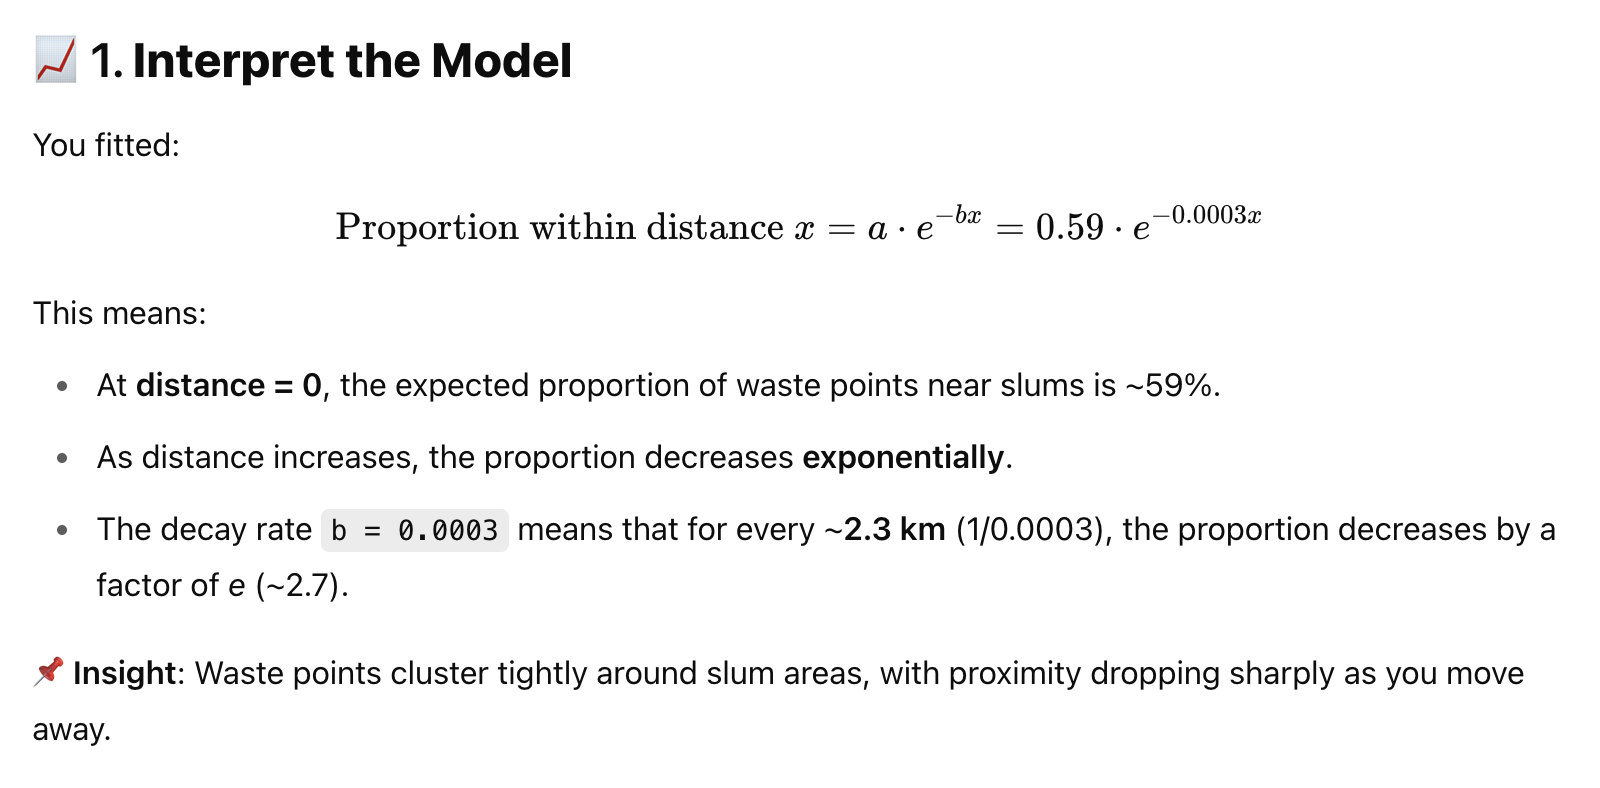
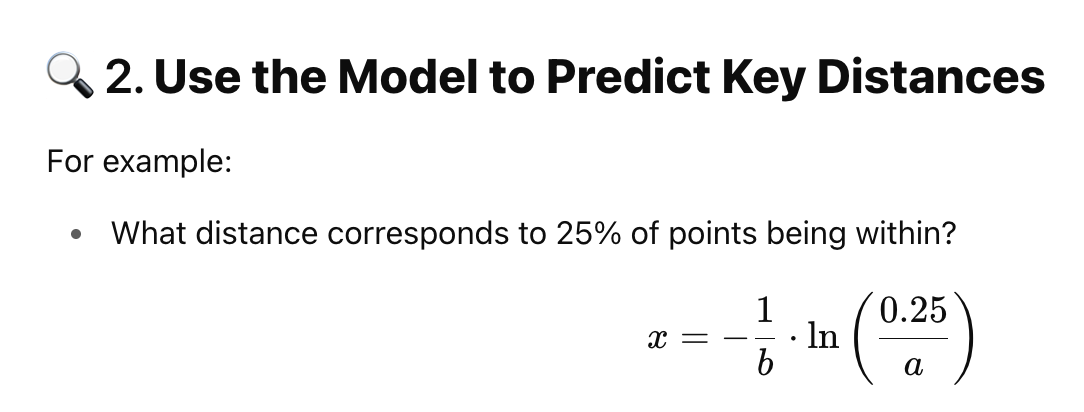

In [ ]:
a = 0.59
b = 0.0003
target_proportion = 0.25

# Solve for distance
x_at_25_percent = -np.log(target_proportion / a) / b
print(f"Distance where 25% of points are within: {x_at_25_percent:.0f} meters")


In [ ]:
# True vs predicted
y_true = point_df["Proportion"]
y_pred = decay_func(point_df["Distance (m)"], a, b)

r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")


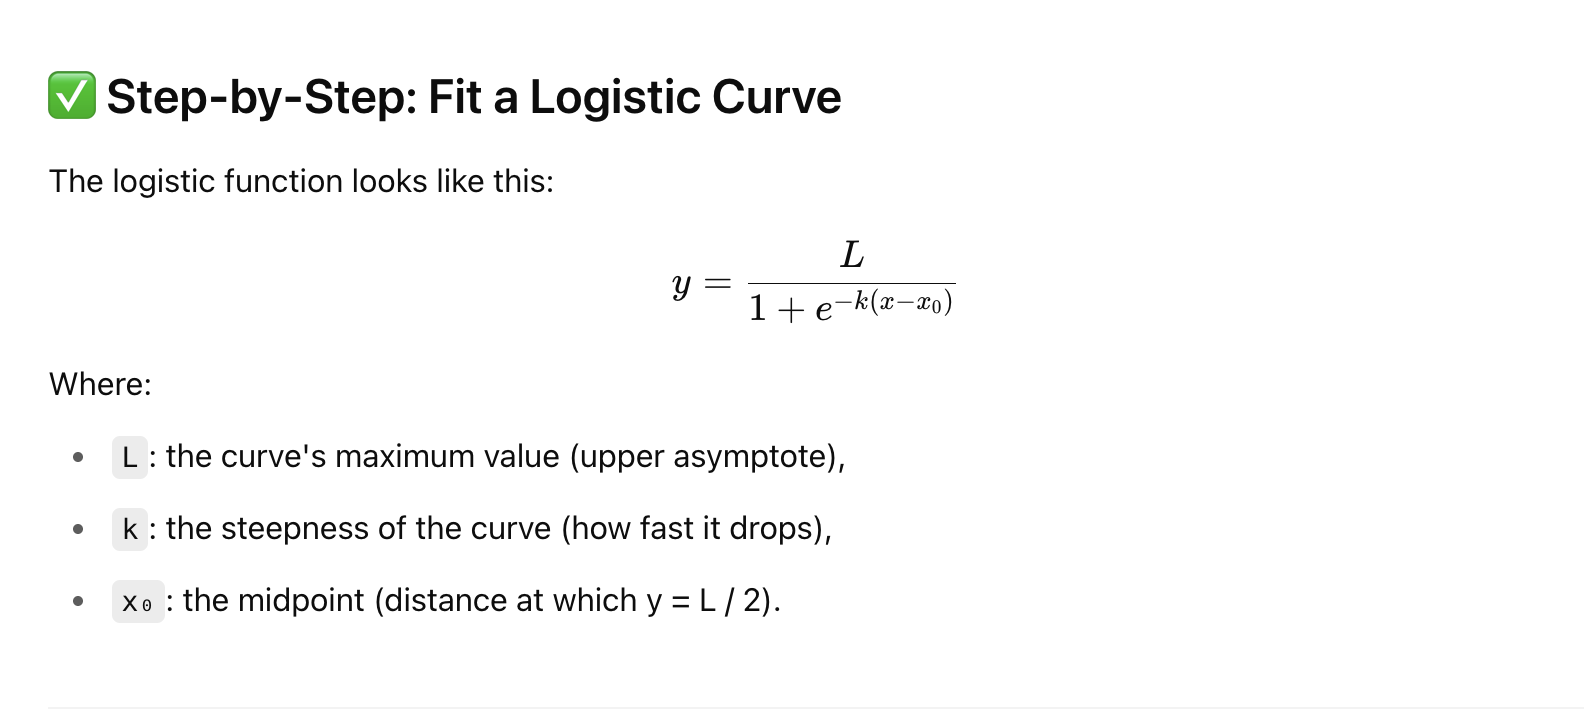

Absolutely — if your exponential model isn't fitting well (especially with an R² < 0), a logistic curve is a smart next move. Logistic functions are great for modeling saturation effects, where the proportion starts near 1 and levels off toward 0 — exactly what you'd expect for spatial decay with limits.

In [ ]:
# Logistic function
def logistic_func(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

# Fit the curve
x_data = point_df["Distance (m)"]
y_data = point_df["Proportion"]

popt_logistic, _ = curve_fit(logistic_func, x_data, y_data, p0=[1, -0.005, 1000])
L, k, x0 = popt_logistic


In [ ]:
# x_fit = np.linspace(0, 2000, 300)
# y_fit_logistic = logistic_func(x_fit, *popt_logistic)

# # Plot
# plt.figure(figsize=(10, 10))
# sns.scatterplot(x=x_data, y=y_data, label="Observed", color="#ac8260")
# plt.plot(x_fit, y_fit_logistic, color="firebrick", label=f"Logistic Fit\nL={L:.2f}, k={k:.4f}, x0={x0:.0f}")
# plt.title("Logistic Decay of Waste Proximity to Slum Boundaries")
# plt.xlabel("Distance to Slum (m)")
# plt.ylabel("Proportion Within Distance")
# plt.ylim(0, 1.05)
# plt.legend()
# plt.tight_layout()

# plt.show()

In [ ]:
y_pred_logistic = logistic_func(x_data, *popt_logistic)
r2_logistic = r2_score(y_data, y_pred_logistic)
rmse_logistic = np.sqrt(mean_squared_error(y_data, y_pred_logistic))

print(f"Logistic Fit → R²: {r2_logistic:.3f}, RMSE: {rmse_logistic:.3f}")

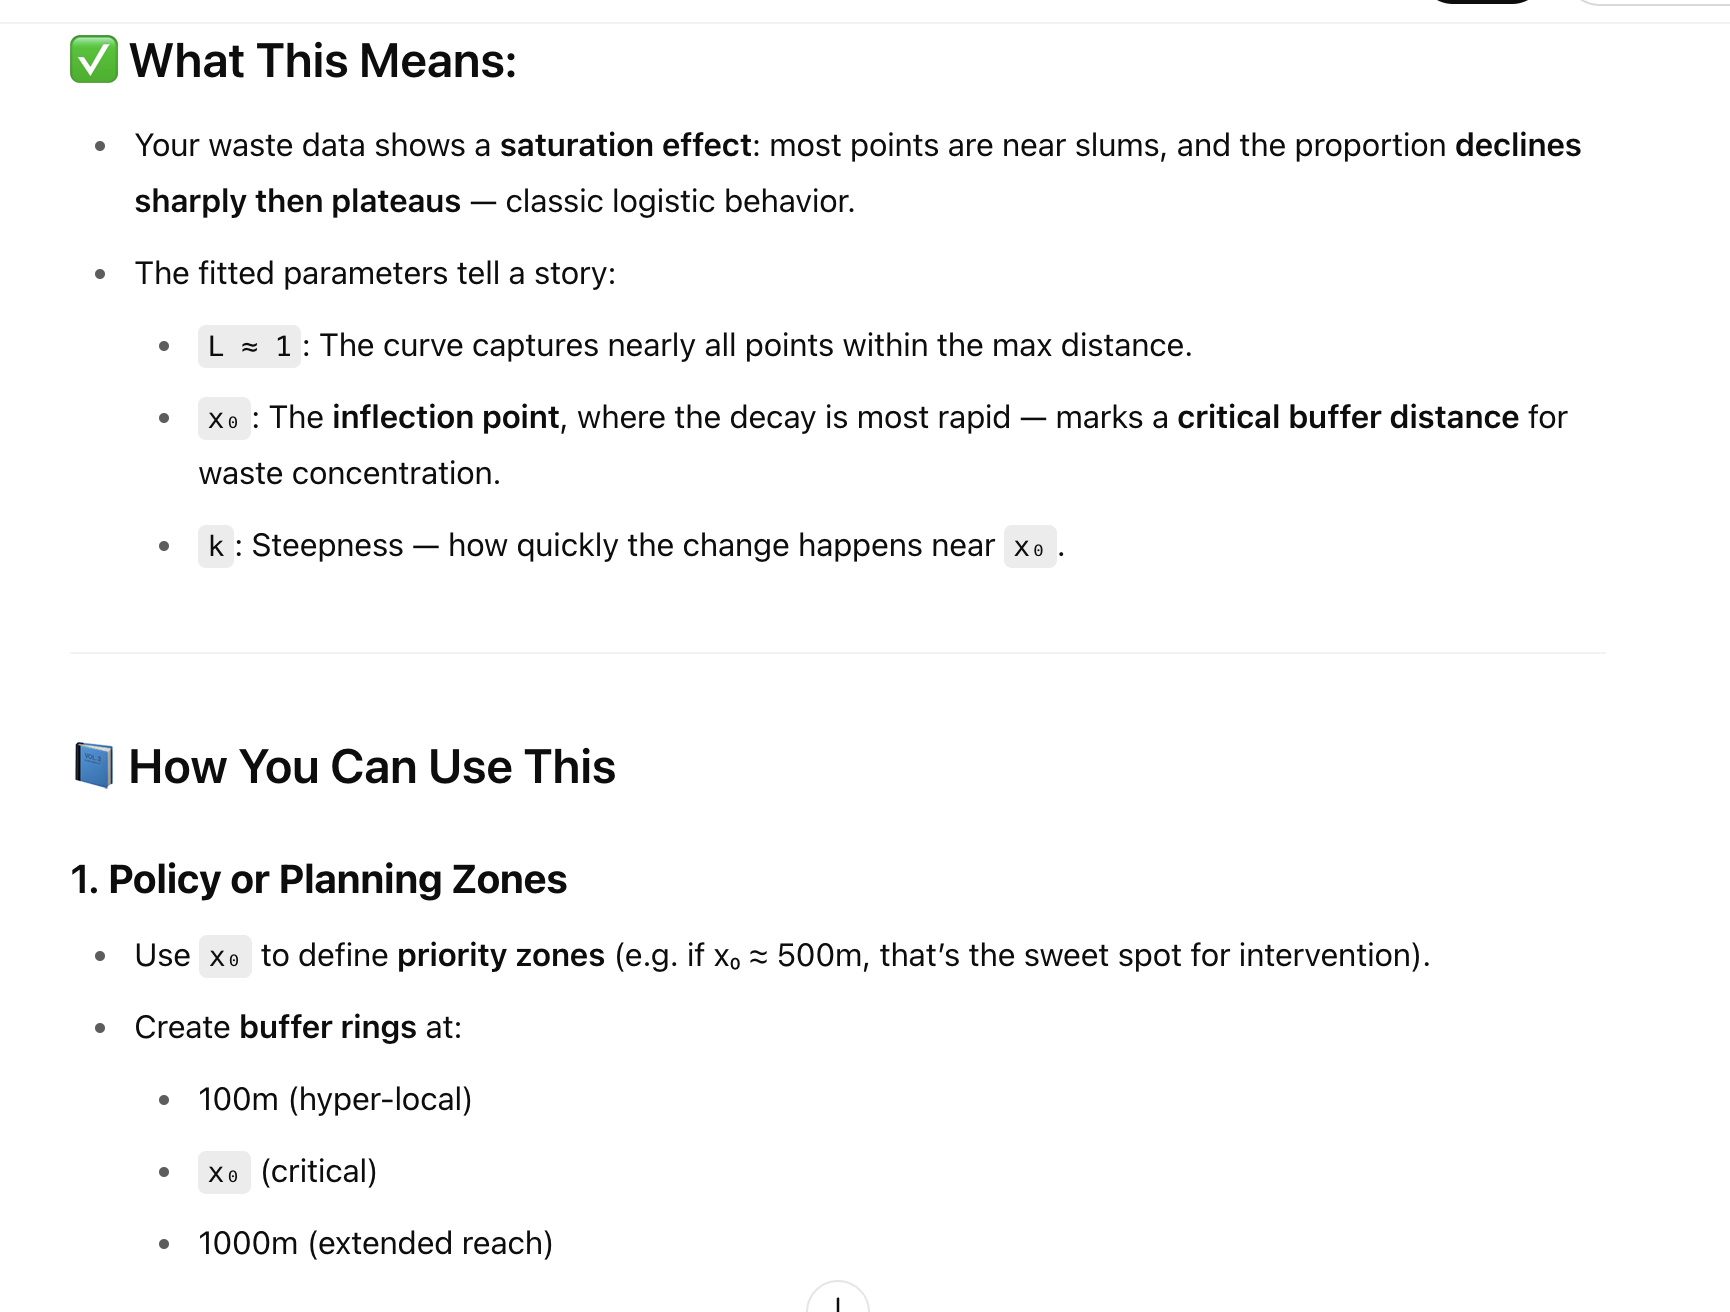

In [ ]:
# plt.figure(figsize=(12, 6))
# sns.scatterplot(x=x_data, y=y_data, label="Observed", color="steelblue")
# plt.plot(x_fit, y_fit_logistic, color="firebrick", label="Logistic Fit")
# plt.axvline(x0, color='gray', linestyle='--', label=f"Inflection Point ≈ {x0:.0f} m")
# plt.title("Waste Proximity Logistic Decay from Slum Boundaries")
# plt.xlabel("Distance to Slum (m)")
# plt.ylabel("Proportion Within Distance")
# plt.ylim(0, 1.05)
# plt.legend()
# plt.tight_layout()
# plt.show()


In [ ]:
def logistic_derivative(x, L, k, x0):
    return (L * k * np.exp(-k * (x - x0))) / ((1 + np.exp(-k * (x - x0))) ** 2)

In [ ]:
# Reuse fitted values
popt_logistic, _ = curve_fit(logistic_func, x_data, y_data, p0=[1, -0.005, 1000])
L, k, x0 = popt_logistic

# Compute fitted curve
x_fit = np.linspace(0, 2000, 300)
y_fit = logistic_func(x_fit, L, k, x0)

# Compute derivative (slope) at inflection
slope_at_x0 = logistic_derivative(x0, L, k, x0)
y0 = logistic_func(x0, L, k, x0)

# Plot
plt.figure(figsize=(10, 10))
sns.scatterplot(x=x_data, y=y_data, label="Observed", color="#ac8260")
plt.plot(x_fit, y_fit, color="firebrick", label="Logistic Fit")

# Add inflection point marker
plt.scatter(x0, y0, color='black', zorder=5, label="Inflection Point")
plt.axvline(x0, color='gray', linestyle='--')
plt.axhline(y0, color='gray', linestyle='--')

# Annotate values
plt.text(x0 + 50, y0 - 0.1, f"$x_0$ = {x0:.0f} m\nSlope = {slope_at_x0:.3f}", fontsize=12, color='black')

# Final touches
plt.title("Waste Point Decay Relative to Slum Boundaries\n(Logistic Model with Inflection Point)", fontsize=14)
plt.xlabel("Distance to Slum (m)")
plt.ylabel("Proportion Within Distance")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'Figure/LogisticModel.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
plt.figure(figsize=(10, 10))

# Observed points
sns.scatterplot(x=x_data, y=y_data, label="Observed (Waste Points)", color="#ac8260")
sns.scatterplot(x=x_data_img, y=y_data_img, label="Observed (Images)", color="black")

# Fitted curves
plt.plot(x_fit, y_fit_waste, color="firebrick", label="Logistic Fit (Waste Points)")
plt.plot(x_fit, y_fit_img, color="black", linestyle='--', label="Logistic Fit (Images)")

# Inflection points
plt.scatter(x0_w, y0_w, color='firebrick', label="Inflection (Waste)", zorder=5)
plt.scatter(x0_i, y0_i, color='black', label="Inflection (Images)", zorder=5)

# Guide lines and annotations
plt.axvline(x0_w, color='firebrick', linestyle=':')
plt.axvline(x0_i, color='black', linestyle=':')
plt.axhline(y0_w, color='firebrick', linestyle=':', linewidth=1)
plt.axhline(y0_i, color='black', linestyle=':', linewidth=1)

# Annotate
plt.text(x0_w + 30, y0_w - 0.08, f"$x_0$ = {x0_w:.0f} m\nSlope = {slope_w:.3f}", color='firebrick', fontsize=11)
plt.text(x0_i + 30, y0_i - 0.08, f"$x_0$ = {x0_i:.0f} m\nSlope = {slope_i:.3f}", color='black', fontsize=11)

# Final touches
plt.title("Logistic Model Fit: Waste vs Image Proximity to Slum Boundaries", fontsize=14)
plt.xlabel("Distance to Slum (m)")
plt.ylabel("Proportion Within Distance")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'Figure/LogisticModel_Waste_vs_Images.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()


In [ ]:
# --- Filter to 'All Images' data ---
all_images_df = plot_df[plot_df["Level"] == "All Images"].copy()
x_data = all_images_df["Distance (m)"].values
y_data = all_images_df["Proportion"].values

# --- Fit logistic curve ---
from scipy.optimize import curve_fit

def logistic_func(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def logistic_derivative(x, L, k, x0):
    e = np.exp(-k * (x - x0))
    return (L * k * e) / ((1 + e) ** 2)

# Initial guess: L=1, k=-0.005, x0=1000
popt_logistic, _ = curve_fit(logistic_func, x_data, y_data, p0=[1, -0.005, 1000])
L, k, x0 = popt_logistic

# --- Compute fitted curve and inflection ---
x_fit = np.linspace(0, 2000, 300)
y_fit = logistic_func(x_fit, L, k, x0)
slope_at_x0 = logistic_derivative(x0, L, k, x0)
y0 = logistic_func(x0, L, k, x0)

# --- Plotting ---
plt.figure(figsize=(10, 10))

# Observed data
sns.scatterplot(x=x_data, y=y_data, label="Observed (All Images)", color="#4C4C4C")

# Logistic curve
plt.plot(x_fit, y_fit, color="firebrick", label="Logistic Fit")

# Inflection point marker
plt.scatter(x0, y0, color='black', zorder=5, label="Inflection Point")
plt.axvline(x0, color='gray', linestyle='--')
plt.axhline(y0, color='gray', linestyle='--')

# Annotate inflection point
plt.text(x0 + 50, y0 - 0.1, f"$x_0$ = {x0:.0f} m\nSlope = {slope_at_x0:.3f}", fontsize=12, color='black')

# Labels and titles
plt.title("Waste Image Density Relative to Slum Boundaries\n(Logistic Fit with Inflection Point)", fontsize=14)
plt.xlabel("Distance to Slum (m)")
plt.ylabel("Proportion Within Distance")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

# Save
plt.savefig(DATA_DIR / 'Figure/LogisticModel_AllImages.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()


In [ ]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Logistic function definitions ---
def logistic_func(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def logistic_derivative(x, L, k, x0):
    e = np.exp(-k * (x - x0))
    return (L * k * e) / ((1 + e) ** 2)

# --- Fit logistic to given subset ---
def fit_logistic(sub_df):
    x = sub_df["Distance (m)"].values
    y = sub_df["Proportion"].values
    popt, _ = curve_fit(logistic_func, x, y, p0=[1, -0.005, 1000])
    return popt, x, y

# --- Prepare plot data ---
fit_data = {
    "All Images": {"color": "#7b5032", "label": "All Images"},
    "All Points": {"color": "#e4c8b0", "label": "All Points"},
}

# colors = ["#7b5032", "#ad8260", "#e4c8b0", "#fbf5ee"]  # dark brown to light gray


x_fit = np.linspace(0, 2000, 300)
plt.figure(figsize=(12, 8))

for level, style in fit_data.items():
    sub_df = plot_df[plot_df["Level"] == level].copy()
    (L, k, x0), x_data, y_data = fit_logistic(sub_df)
    
    # Store values
    y_fit = logistic_func(x_fit, L, k, x0)
    slope = logistic_derivative(x0, L, k, x0)
    y0 = logistic_func(x0, L, k, x0)

    # Plot scatter + curve
    sns.scatterplot(x=x_data, y=y_data, label=f"Observed ({style['label']})", color=style["color"], alpha=0.6)
    plt.plot(x_fit, y_fit, label=f"Logistic Fit ({style['label']})", color=style["color"], linewidth=2)

    # Inflection point
    plt.scatter(x0, y0, color=style["color"], edgecolor='black', s=80, zorder=5)
    plt.axvline(x0, color=style["color"], linestyle='--', alpha=0.5)
    
    # Annotate
    plt.text(
        x0 + 30, y0 - 0.12,
        f"{style['label']}\n$x_0$ = {x0:.0f} m\nSlope = {slope:.3f}",
        color=style["color"],
        fontsize=11
    )

# --- Final plot settings ---
plt.title("Logistic Fit of Waste Proximity to Slums\n(All Images vs All Points)", fontsize=15)
plt.xlabel("Distance to Slum Boundary (m)")
plt.ylabel("Proportion Within Distance")
plt.ylim(0, 1.05)
plt.xlim(0, 2000)
plt.legend()
plt.tight_layout()

# Save the figure
# plt.savefig(DATA_DIR / "Figure/LogisticModel_Images_vs_AllPoints.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

# --- Logistic function definitions ---
def logistic_func(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def logistic_derivative(x, L, k, x0):
    e = np.exp(-k * (x - x0))
    return (L * k * e) / ((1 + e) ** 2)

# --- Fit logistic to given subset ---
def fit_logistic(sub_df):
    x = sub_df["Distance (m)"].values
    y = sub_df["Proportion"].values
    popt, _ = curve_fit(logistic_func, x, y, p0=[1, -0.005, 1000])
    y_pred = logistic_func(x, *popt)
    
    # Metrics
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    return popt, x, y, y_pred, r2, rmse

# --- Plot config ---
fit_data = {
    "All Images": {"color": "#7b5032", "label": "All Images"},
    "All Points": {"color": "#e4c8b0", "label": "Waste Points"},
}

x_fit = np.linspace(0, 2000, 300)
# plt.figure(figsize=(12, 8))
plt.figure(figsize=(8, 8))

for level, style in fit_data.items():
    sub_df = plot_df[plot_df["Level"] == level].copy()
    popt, x_data, y_data, y_pred, r2, rmse = fit_logistic(sub_df)
    L, k, x0 = popt

    # Fitted curve + values
    y_fit = logistic_func(x_fit, L, k, x0)
    y0 = logistic_func(x0, L, k, x0)
    slope = logistic_derivative(x0, L, k, x0)

    # Plot data and fit
    sns.scatterplot(x=x_data, y=y_data, label=f"Observed ({style['label']})", color=style["color"], alpha=0.6)
    plt.plot(x_fit, y_fit, label=f"Logistic Fit ({style['label']})", color=style["color"], linewidth=2)

    # Inflection marker
    plt.scatter(x0, y0, color=style["color"], edgecolor='black', s=80, zorder=5)
    plt.axvline(x0, color=style["color"], linestyle='--', alpha=0.5)

    # Annotate with metrics
    annotation = (
        f"{style['label']}\n"
        f"$x_0$ = {x0:.0f} m\n"
        f"Slope = {slope:.3f}\n"
        f"$R^2$ = {r2:.3f}\n"
        f"RMSE = {rmse:.3f}"
    )
    plt.text(
        x0 + 30, y0 - 0.12,
        annotation,
        color=style["color"],
        fontsize=16
    )

# --- Final touches ---
plt.title("Logistic Fit of Waste Proximity to Slums\n(All Images vs Waste Points)", fontsize=15)
plt.xlabel("Distance to Slum Boundary (m)")
plt.ylabel("Proportion Within Distance")
plt.ylim(0, 1.05)
plt.xlim(0, 2000)
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig(DATA_DIR / "Figure/LogisticModel_Images_vs_AllPoints_Stats88.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()


In [ ]:
import pandas as pd

# --- Collect fit info for each level ---
summary_rows = []

for level, style in fit_data.items():
    sub_df = plot_df[plot_df["Level"] == level].copy()
    popt, x_data, y_data, y_pred, r2, rmse = fit_logistic(sub_df)
    L, k, x0 = popt
    slope = logistic_derivative(x0, L, k, x0)
    
    summary_rows.append({
        "Level": level,
        "L (Max Proportion)": round(L, 4),
        "k (Growth Rate)": round(k, 6),
        "x0 (Inflection Point m)": round(x0, 2),
        "Slope at x0": round(slope, 4),
        "R²": round(r2, 4),
        "RMSE": round(rmse, 4)
    })

# --- Create and display DataFrame ---
summary_df = pd.DataFrame(summary_rows)
summary_df

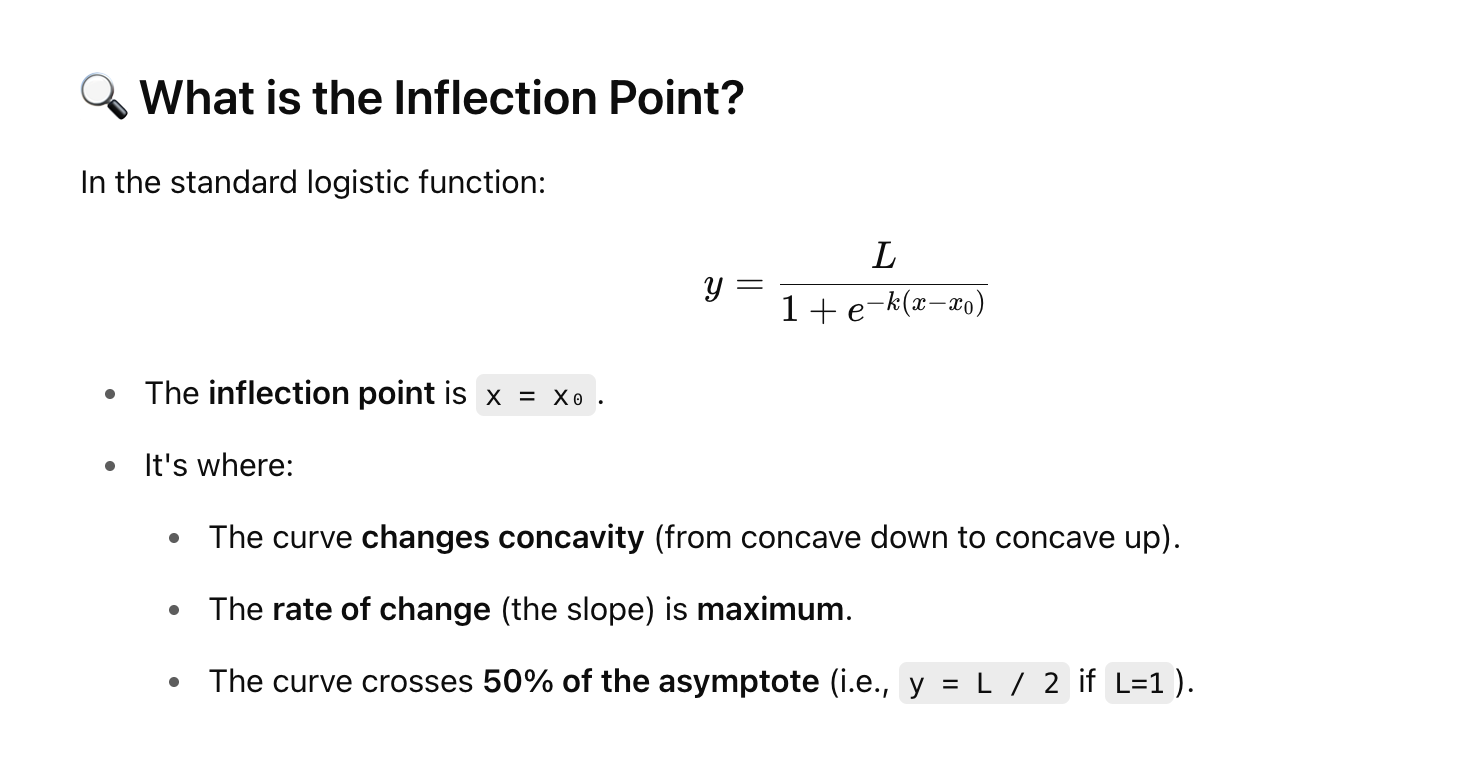

In [ ]:
len(x_fit)

In [ ]:
# --- Store fitted parameters for both datasets ---
fitted_models = {}

for level in ["All Points", "All Images"]:
    sub_df = plot_df[plot_df["Level"] == level].copy()
    popt, *_ = fit_logistic(sub_df)  # Unpack all, but only use popt
    fitted_models[level] = {
        "L": popt[0],
        "k": popt[1],
        "x0": popt[2]
    }


# --- Prepare x values ---
x_fit = np.linspace(0, 2000, 300)

# --- Plot derivatives ---
plt.figure(figsize=(10, 5))

colors = {
    "All Points": "#e4c8b0",
    "All Images": "#7b5032"
}

for level, params in fitted_models.items():
    L, k, x0 = params["L"], params["k"], params["x0"]
    y_derivative = logistic_derivative(x_fit, L, k, x0)
    
    # Plot the curve
    plt.plot(x_fit, y_derivative, label=f"{level} ($x_0$ ≈ {x0:.0f} m)", color=colors[level])
    plt.axvline(x0, color=colors[level], linestyle='--', alpha=0.6)
    
    # Get y-value at inflection
    y0 = logistic_derivative(x0, L, k, x0)
    
    # Annotate
    annotation = (
        f"{level}\n"
        f"$x_0$ = {x0:.0f} m\n"
        f"Slope = {y0:.3f}"
    )
    
    plt.text(
        x0 + 20, y0-0.0002,  # tweak offsets as needed
        annotation,
        fontsize=10,
        color=colors[level],
        ha='left',
        va='bottom'
    )

# --- Final plot settings ---
plt.title("Logistic Derivative: Rate of Change vs. Distance to Slum")
plt.xlabel("Distance to Slum Boundary (m)")
plt.ylabel("Change in Proportion per Meter")
plt.legend(title="Dataset")
plt.tight_layout()
plt.savefig(DATA_DIR / "Figure/Logistic_derivative.png", dpi=600, bbox_inches='tight', transparent=True)

plt.show()

In [ ]:
def logistic_derivative(x, L, k, x0):
    exp_term = np.exp(-k * (x - x0))
    return (L * k * exp_term) / (1 + exp_term)**2

y_derivative = logistic_derivative(x_fit, L, k, x0)

plt.figure(figsize=(10, 5))
plt.plot(x_fit, y_derivative, color="purple", label="Rate of Change")
plt.axvline(x0, color='gray', linestyle='--', label=f"Inflection Point ≈ {x0:.0f} m")
plt.title("Logistic Curve Derivative (Max Change at Inflection)")
plt.xlabel("Distance to Slum (m)")
plt.ylabel("Change in Proportion per Meter")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Total number of waste points in the dataset
num_points = len(waste_Nairobi_gdf)
print(f"Total waste points: {num_points}")

In [ ]:
# Derivative of the logistic curve (rate of change)
def logistic_derivative(x, L, k, x0):
    exp_term = np.exp(-k * (x - x0))
    return (L * k * exp_term) / (1 + exp_term)**2

y_derivative = logistic_derivative(x_fit, *popt_logistic)

plt.figure(figsize=(12, 5))
plt.plot(x_fit, y_derivative, color="purple")
plt.title("Rate of Change of Waste Proximity (Logistic Derivative)")
plt.xlabel("Distance to Slum (m)")
plt.ylabel("Change in Proportion per Meter")
plt.tight_layout()
plt.show()


In [ ]:
# Count points per cluster
cluster_counts = waste_Nairobi_gdf[check_cluster].value_counts().sort_index()

print("Number of points per cluster:")
print(cluster_counts)

# Optional: summarize clusters with fewer than 10 points
small_clusters = cluster_counts[cluster_counts < 10]
print("\nClusters with fewer than 10 points:")
print(small_clusters)

# Optional: visualize distribution of cluster sizes
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
cluster_counts.plot(kind='bar')
plt.title("Number of Points per Cluster")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Points")
plt.axhline(10, color='red', linestyle='--', label='Threshold (10 points)')
plt.legend()
plt.tight_layout()
plt.show()


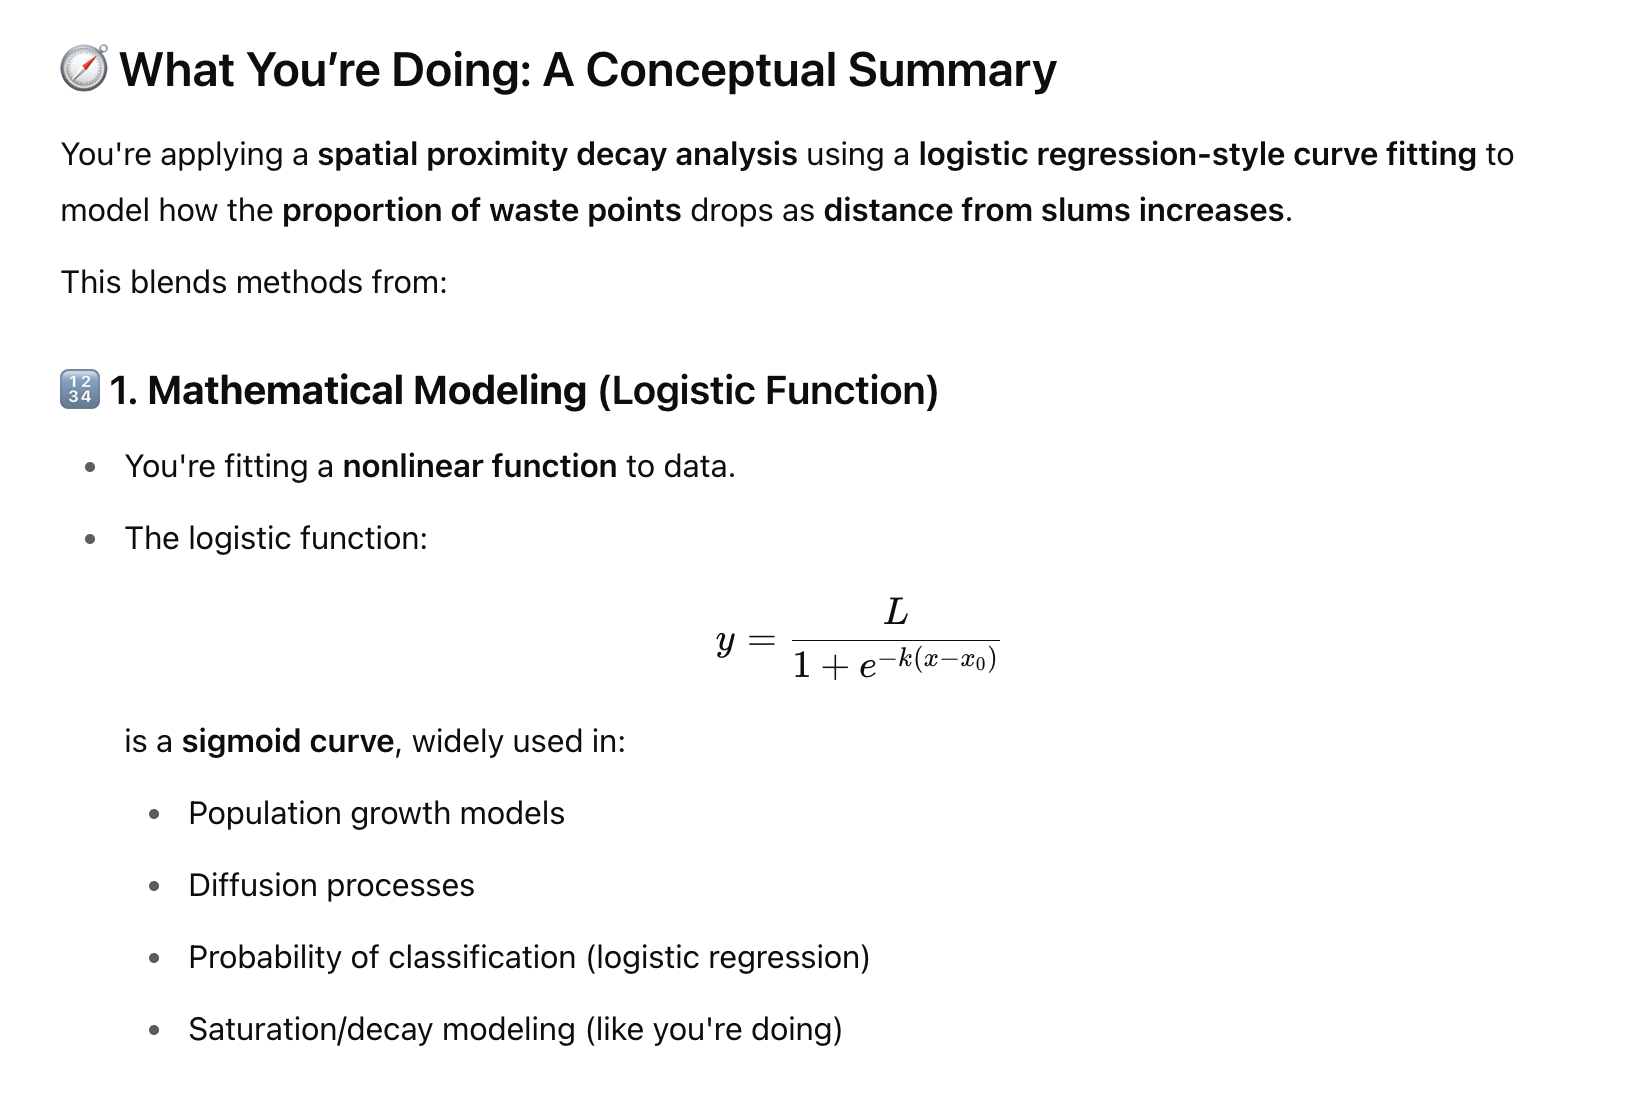
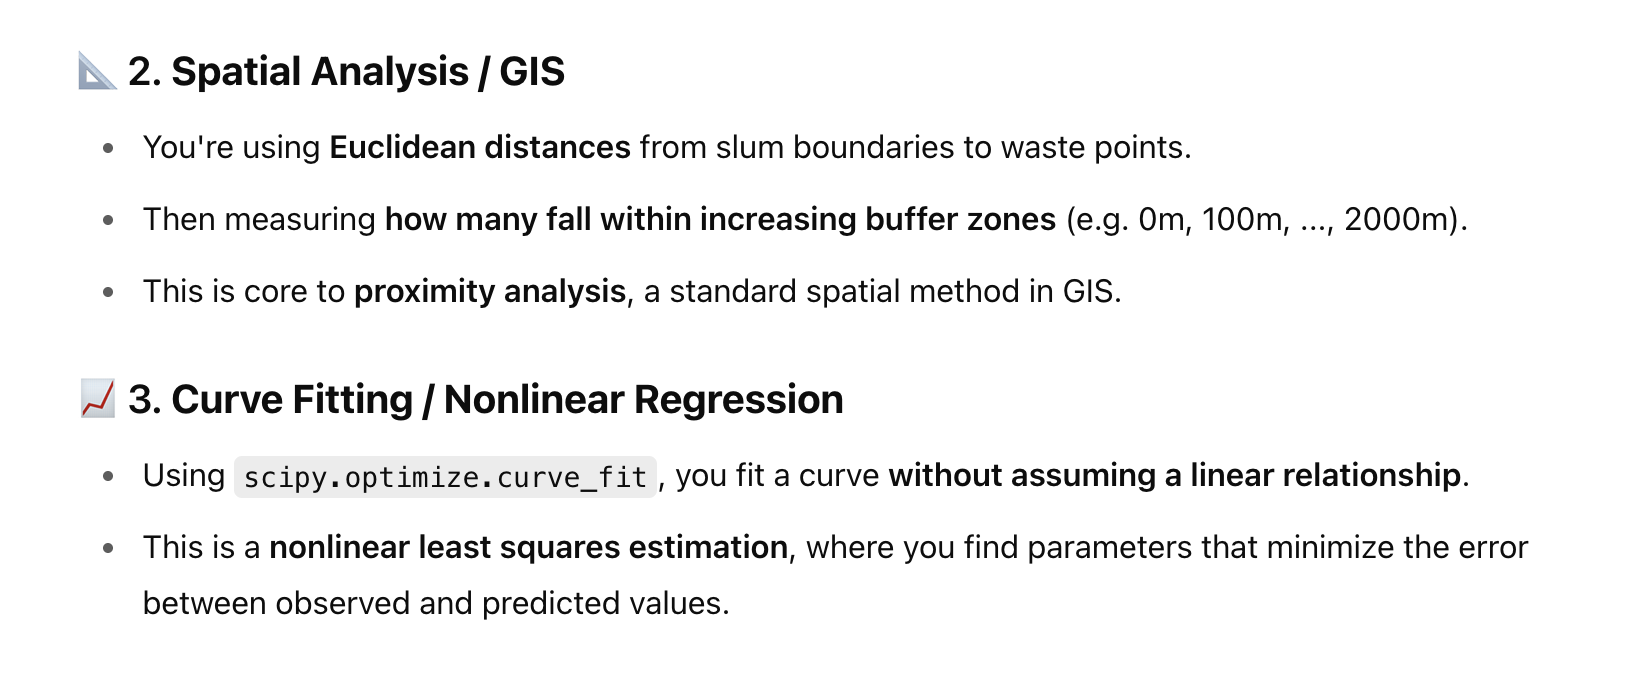
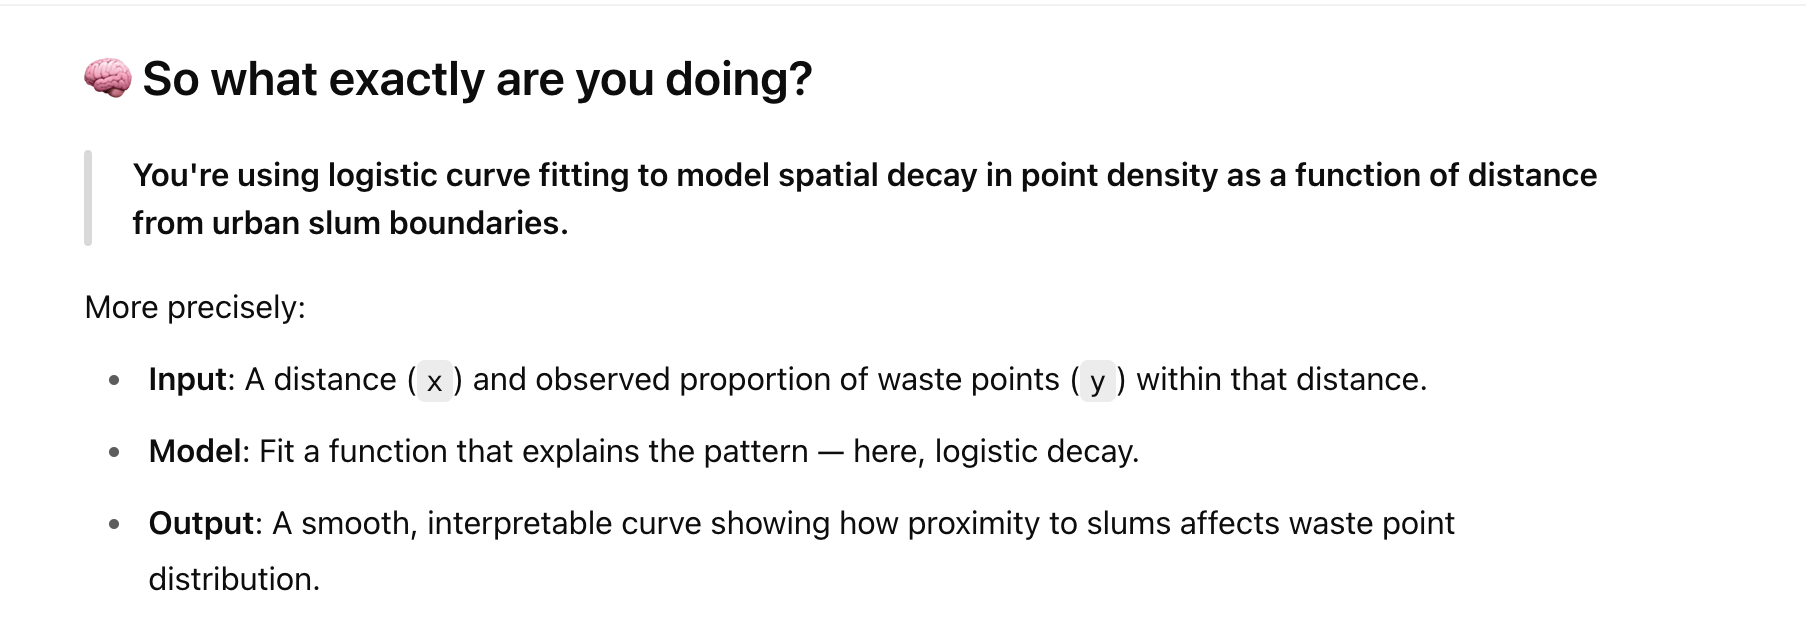
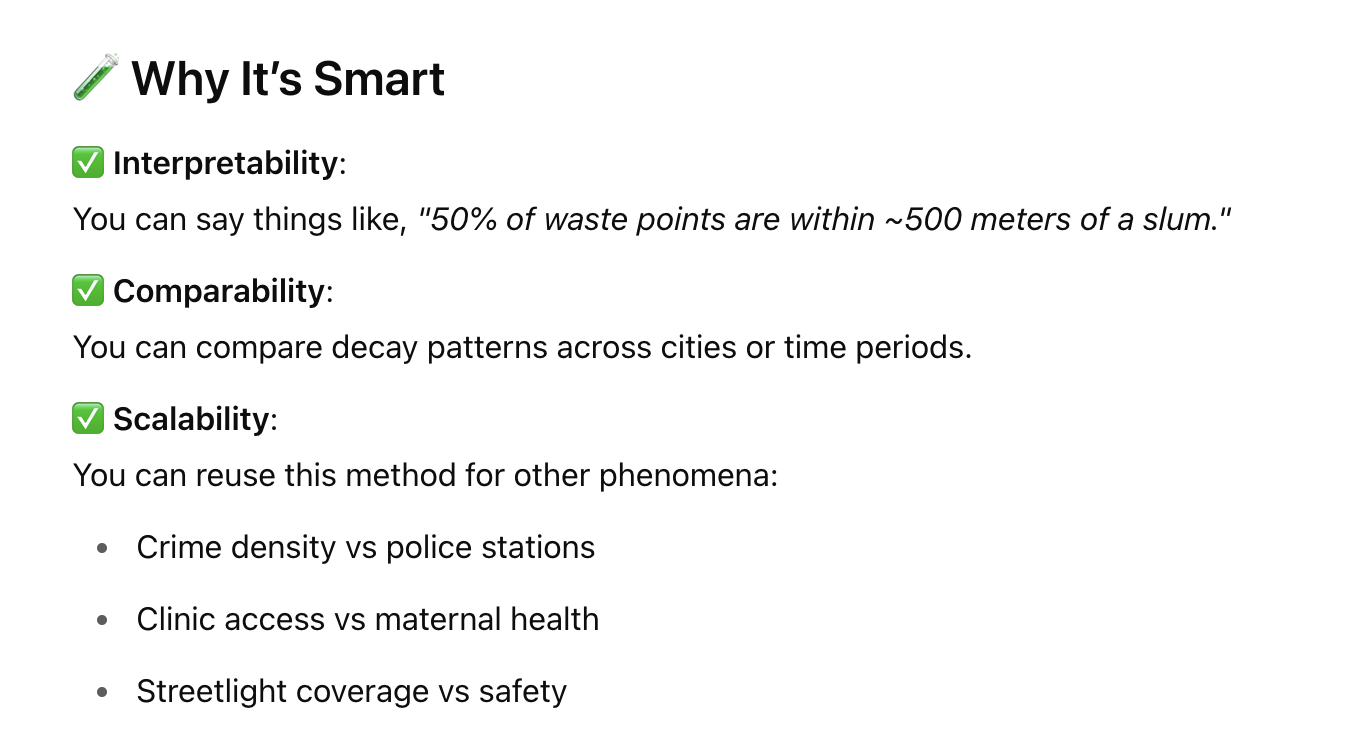
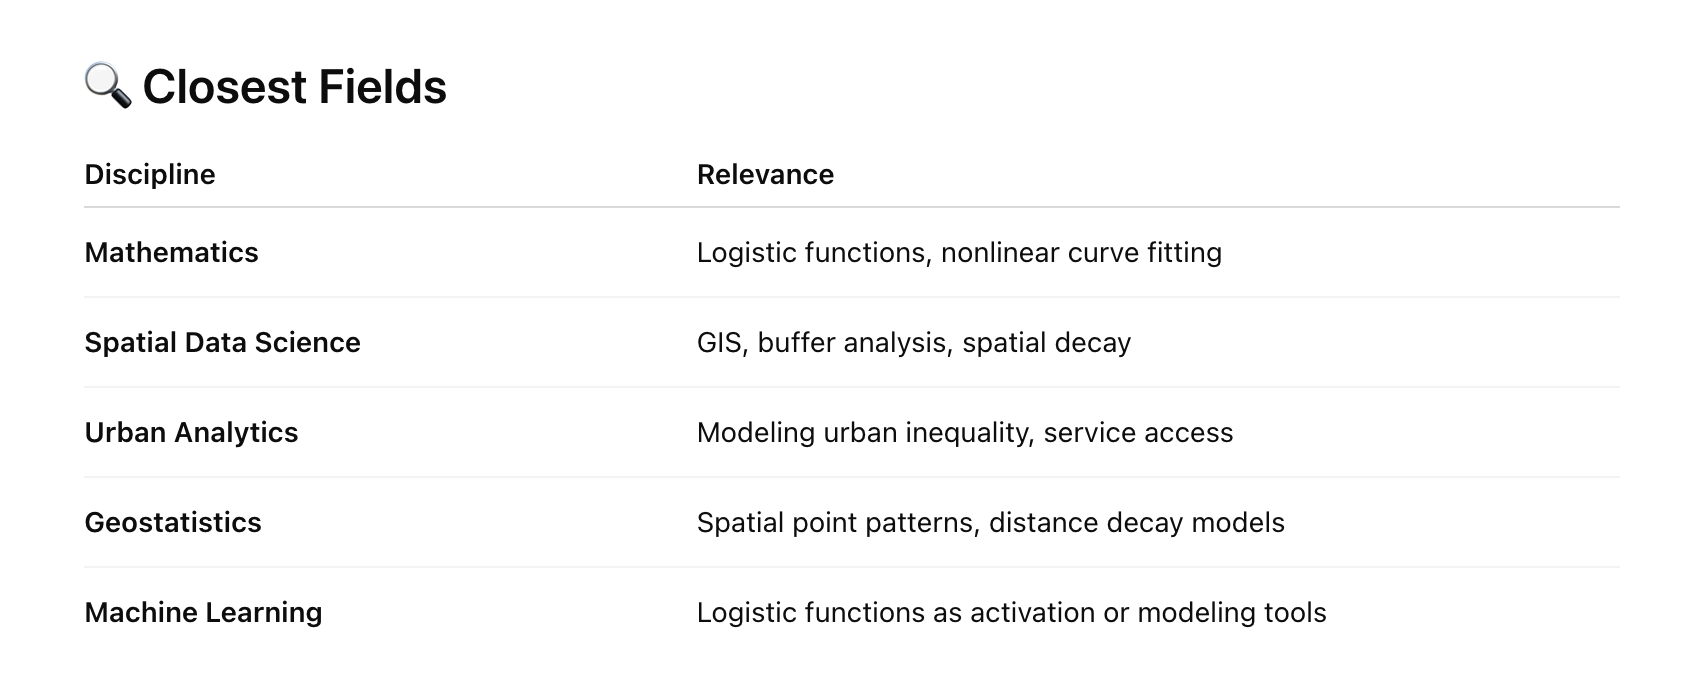

# What You Already Have (and it’s strong):
1. Clear Research Question
You're addressing:

How does proximity to informal settlements affect the spatial distribution of waste dumping?

This is timely, urban-relevant, and understudied in many regions.

2. Strong Methodology
Proximity buffer analysis

Spatial point processing

Logistic decay curve fitting

Cluster vs point-level comparison

Density metrics inside vs outside slums

3. Quantitative Results
R² = 0.988 with a clear logistic pattern

Density inside slums ≈ 7× higher than outside

Visualization of inflection points, cluster bar charts, and buffer effects

4. Policy Implications
You can argue for:

Targeted waste services within 500m of slums

Predictive zoning based on slum proximity

Equity-based urban service planning

# 🧩 What Could Make It a Complete Paper
To publish in a peer-reviewed journal or conference, you usually need:

🧪 1. Validation / Comparison
Apply the method to multiple cities or slum areas

Compare models (linear, exponential, logistic, piecewise)

📊 2. Temporal or Contextual Layer
Add time: how has waste proximity changed over months or years?

Add infrastructure: are waste points closer to unserved areas?

🗺️ 3. Deeper Spatial Context
Overlay roads, population density, or land use

Are some slums more “attractive” for dumping based on context?

📚 4. Theoretical Framing
Tie it to theories of spatial inequality, environmental justice, or urban informality

Cite literature on waste management in low-income urban contexts



| Use Case                    | Enough as is? | What to add for full paper                        |
| --------------------------- | ------------- | ------------------------------------------------- |
| **Class project or thesis** | ✅ Yes         | Polish visuals + intro/conclusion                 |
| **Policy brief/report**     | ✅ Yes         | Add 1–2 concrete recommendations                  |
| **Conference short paper**  | ✅ Mostly      | Consider comparing 2 areas or models              |
| **Peer-reviewed journal**   | 🔄 Not yet    | Add validation, contextual layers, and lit review |


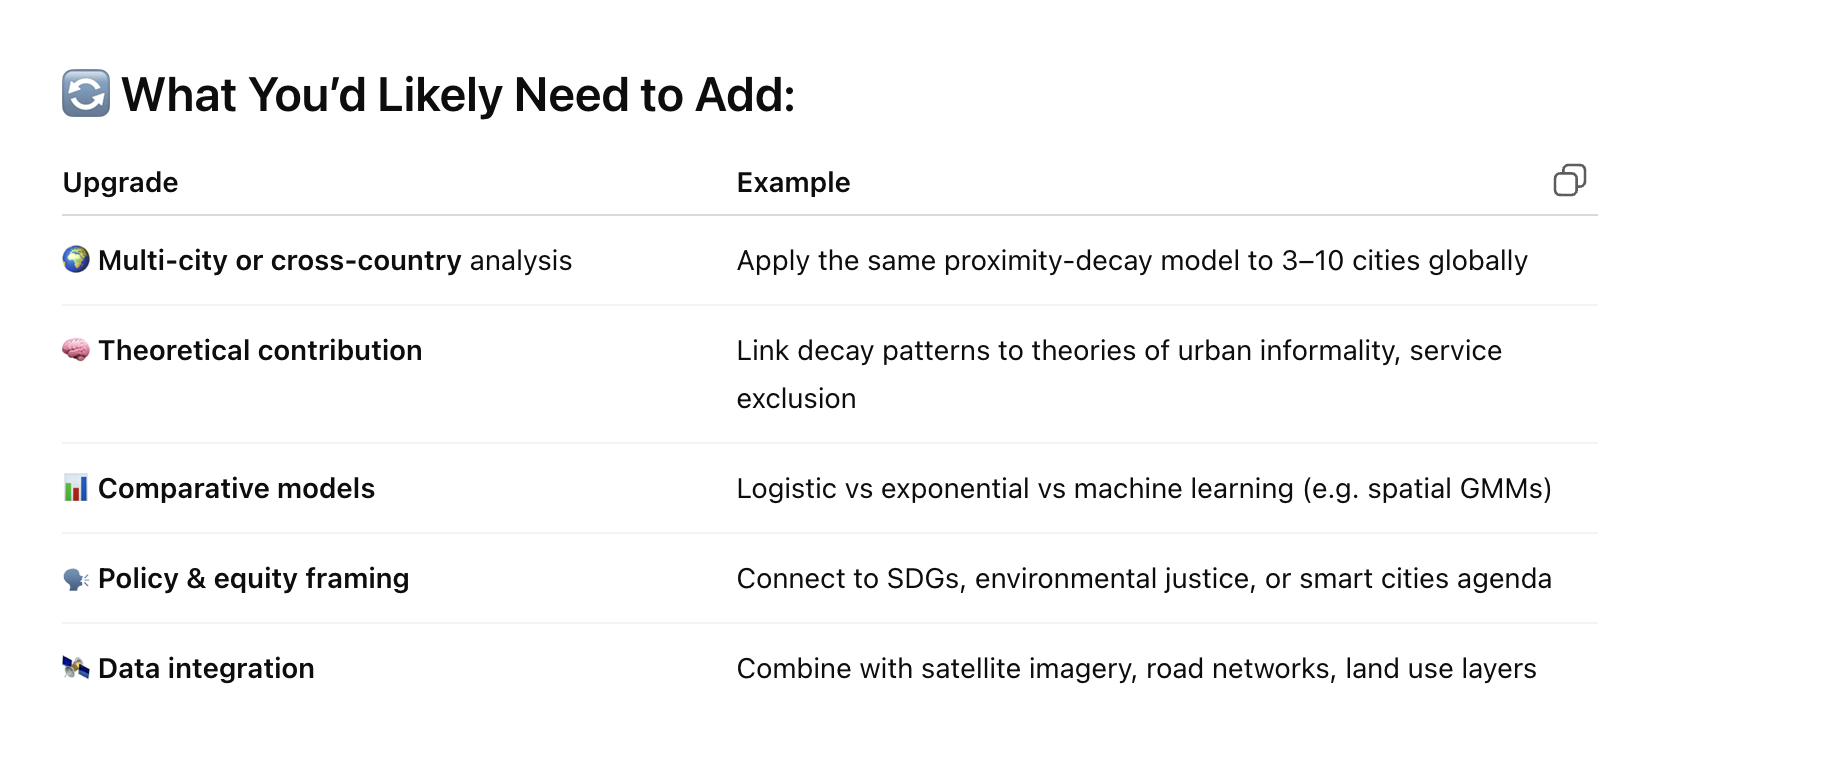